# DNN PEAD — Trading Strategy Backtest

Buy when predicted class is 1 or 2. Exit at take-profit/stop-loss or t+10 close.

## Strategy 1 (2% Threshold)
Exit at 2% if stock reaches it, otherwise at t+10 close. Baseline strategy.

## Strategy 2 (Threshold Sweep)
Sweep 1%-5% (step 0.5%). Pick best threshold by Sharpe.

## Strategy 3 (Split-Sell)
Using best T from Strat 2. Sell a fraction at partial threshold,
remainder at full T or t+10. Tests split ratios: 70/30, 60/40, 50/50.

## Strategy 4 (Final — 5% TP + Stop-Loss Sweep)
2% take-profit with stop-loss sweep (-1% to -5%, 0.5% step).
Best SL selected by Sharpe. Full analytics suite + Sortino ratio.

## Rules
- Initial capital: $50,000 · Position: $200 per trade
- Entry at t+1 close · Exit at TP/SL crossing or t+10 close
- Cash-constrained simulation with chronological event processing
- Return denominator = deployed capital (not total capital)


In [62]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 100, "font.size": 9})

In [63]:
# ── Paths (try repo-root relative first, then notebook-relative) ──────
RESULTS_PATH = Path("src/modeling/model_outputs/dnn_outputs/results.parquet")
if not RESULTS_PATH.exists():
    RESULTS_PATH = Path("../model_outputs/dnn_outputs/results.parquet")

STRAT_TABLE_PATH = Path("src/data/model_staging/strat_table.parquet")
if not STRAT_TABLE_PATH.exists():
    STRAT_TABLE_PATH = Path("../../data/model_staging/strat_table.parquet")

# ── Strategy params ───────────────────────────────────────────────────
INITIAL_CAPITAL = 50_000
POSITION_SIZE = 200
THRESHOLDS = np.arange(0.01, 0.0525, 0.005)  # 1% to 10%, step 0.5%

# ── Daily high window: t+2 to t+10 (9 trading days) ──────────────────
DRIFT_OFFSETS = list(range(2, 11))  # [2, 3, ..., 10]

---
## 1. Load & merge data

In [64]:
# ── Load results, filter to buy signals ───────────────────────────────
results = pl.read_parquet(RESULTS_PATH)
signals = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
# filter out earnings dates that are greater than 2025
signals = signals.filter(pl.col("earnings_date") < pl.datetime(2026, 1, 1))
print(f"Buy signals: {len(signals):,}")

# ── Load precomputed strategy table ──────────────────────────────────
daily = pl.read_parquet(STRAT_TABLE_PATH)

# The forward high/low/date columns and entry/exit values are built in
# technical_features.py so this notebook only joins the finished table.
join_cols = ["symbol", "date", "entry_date", "close_t10"]
for offset in DRIFT_OFFSETS:
    join_cols += [
        f"high_t+{offset}",
        f"low_t+{offset}",
        f"date_t+{offset}",
    ]

signals = signals.join(
    daily.select(join_cols),
    left_on=["symbol", "earnings_date"], right_on=["symbol", "date"], how="left",
)

# The strategy requires a complete t+2..t+10 forward window.
# The source table is intentionally capped at 2025-12-31, so recent
# signals can lack their final forward rows. Exclude those trades before
# calculating returns to prevent NaN equity curves.
required_strategy_cols = ["entry_date", "close_t10"]
required_strategy_cols += [f"high_t+{offset}" for offset in DRIFT_OFFSETS]
required_strategy_cols += [f"low_t+{offset}" for offset in DRIFT_OFFSETS]
required_strategy_cols += [f"date_t+{offset}" for offset in DRIFT_OFFSETS]
rows_before_window_filter = len(signals)
signals = signals.drop_nulls(required_strategy_cols)
print(f"Dropped incomplete forward windows: {rows_before_window_filter - len(signals):,}")
signals = signals.with_columns(
    (pl.col("close_t10") / pl.col("entry_price") - 1).alias("close_t10_return")
)
print(f"After join — rows: {len(signals)}, null close_t10: {signals['close_t10_return'].null_count()}")

Buy signals: 5,648
Dropped incomplete forward windows: 0
After join — rows: 5648, null close_t10: 0


In [65]:
daily.schema

Schema([('symbol', String),
        ('date', Date),
        ('high_t+2', Float64),
        ('high_t+3', Float64),
        ('high_t+4', Float64),
        ('high_t+5', Float64),
        ('high_t+6', Float64),
        ('high_t+7', Float64),
        ('high_t+8', Float64),
        ('high_t+9', Float64),
        ('high_t+10', Float64),
        ('low_t+2', Float64),
        ('low_t+3', Float64),
        ('low_t+4', Float64),
        ('low_t+5', Float64),
        ('low_t+6', Float64),
        ('low_t+7', Float64),
        ('low_t+8', Float64),
        ('low_t+9', Float64),
        ('low_t+10', Float64),
        ('date_t+2', Date),
        ('date_t+3', Date),
        ('date_t+4', Date),
        ('date_t+5', Date),
        ('date_t+6', Date),
        ('date_t+7', Date),
        ('date_t+8', Date),
        ('date_t+9', Date),
        ('date_t+10', Date),
        ('entry_date', Date),
        ('close_t10', Float64)])

In [66]:
signals.group_by

<bound method DataFrame.group_by of shape: (5_648, 42)
┌─────────┬──────────┬────────┬────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ quarter ┆ fold_num ┆ symbol ┆ earnings_d ┆ … ┆ high_t+10  ┆ low_t+10   ┆ date_t+10  ┆ close_t10_ │
│ ---     ┆ ---      ┆ ---    ┆ ate        ┆   ┆ ---        ┆ ---        ┆ ---        ┆ return     │
│ str     ┆ i64      ┆ str    ┆ ---        ┆   ┆ f64        ┆ f64        ┆ date       ┆ ---        │
│         ┆          ┆        ┆ date       ┆   ┆            ┆            ┆            ┆ f64        │
╞═════════╪══════════╪════════╪════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 2022_Q1 ┆ 1        ┆ TROW   ┆ 2022-01-27 ┆ … ┆ 126.758642 ┆ 120.931512 ┆ 2022-02-10 ┆ -0.013217  │
│ 2022_Q1 ┆ 1        ┆ V      ┆ 2022-01-27 ┆ … ┆ 222.564884 ┆ 217.648032 ┆ 2022-02-10 ┆ -0.008961  │
│ 2022_Q1 ┆ 1        ┆ STE    ┆ 2022-02-08 ┆ … ┆ 222.321376 ┆ 215.979239 ┆ 2022-02-23 ┆ -0.052244  │
│ 2022_Q1 ┆ 1        ┆ FOX    ┆ 2022

In [67]:
signals.group_by(['target_class_actual', 'target_class_predicted']).len()

target_class_actual,target_class_predicted,len
i64,i64,u32
0,2,1043
1,1,388
2,2,2366
1,2,960
0,1,379
2,1,512


In [68]:
# ── Extract numpy arrays for vectorised threshold sweep ───────────────
HIGH_COLS = [f"high_t+{d}" for d in DRIFT_OFFSETS]
DATE_COLS = [f"date_t+{d}" for d in DRIFT_OFFSETS]

drift_highs = np.column_stack([signals[c].to_numpy() for c in HIGH_COLS])  # (N, 9)
drift_dates = np.column_stack([signals[c].to_numpy() for c in DATE_COLS])  # (N, 9)
entry_prices = signals["entry_price"].to_numpy()
close_t10_ret = signals["close_t10_return"].to_numpy()
close_t10_date = drift_dates[:, -1]
entry_dates = signals["entry_date"].to_numpy().astype("datetime64[D]")
N = len(signals)

# ── Cummax return during drift window per trade ───────────────────────
drift_rets = drift_highs / entry_prices[:, None] - 1
cummax_rets = np.maximum.accumulate(drift_rets, axis=1)

print(f"{N} trades, {len(DRIFT_OFFSETS)} drift days, {len(THRESHOLDS)} thresholds")

5648 trades, 9 drift days, 9 thresholds


---
## 2. Signal Quality

In [69]:
buy_all = results.filter(pl.col("target_class_predicted").is_in([1, 2]))
overall_win = (buy_all["target_class_actual"] >= 1).mean()
print(f"Overall directional win % (actual >= 1): {overall_win:.2%}")
print(f"\n{'Pred':<6} {'Count':>7} {'Win% (≥1)':>11} {'Hit 2%':>8} {'AvgRet':>8}"
      f" {'Low(0)':>7} {'Mod(1)':>7} {'Str(2)':>7}")
print(f"{'-'*65}")
for p in [0, 1, 2]:
    sub = results.filter(pl.col("target_class_predicted") == p)
    win = (sub["target_class_actual"] >= 1).mean()
    hit2 = (sub["target_return_actual"] > 0.02).mean()
    a0, a1, a2 = [(sub["target_class_actual"] == c).sum() for c in [0, 1, 2]]
    print(f"{p:<6} {len(sub):>7,} {win:>11.2%} {hit2:>8.2%}"
          f" {sub['target_return_actual'].mean():>8.2%} {a0:>7} {a1:>7} {a2:>7}")

Overall directional win % (actual >= 1): 74.82%

Pred     Count   Win% (≥1)   Hit 2%   AvgRet  Low(0)  Mod(1)  Str(2)
-----------------------------------------------------------------
0        2,319      61.66%   61.66%    3.21%     889     721     709
1        1,279      70.37%   70.37%    3.88%     379     388     512
2        4,369      76.13%   76.13%    5.71%    1043     960    2366


## Trading Strategy Methodology

### Signal: buy classes 1+2, skip class 0

The DNN classifier outputs 3 predicted classes. We only trade classes 1 (Moderate) and 2 (Strong). Class 0 (Low) is excluded — its win rate is below the combined buy-signal baseline.

### Win condition: directional accuracy

A trade is a win if the **actual peak return falls in class 1 or 2** (>= 2%), regardless of which bucket the model predicted:

| Predicted | Win if actual >= | Rationale |
|---|---|---|
| 1 (Moderate) | 1 (Moderate or Strong) | Stock does not fall to Low |
| 2 (Strong) | 1 (Moderate or Strong) | Stock does not fall to Low |
| 0 (Low) | Not traded | Win rate too low, returns too small |

The model's job is to identify stocks likely to drift upward by at least 2%; which bucket (1 vs 2) determines confidence, not correctness.

### Entry, exit, and sizing

- Entry at t+1 close, exit window t+2 to t+10
- Take-profit at threshold T% if reached; otherwise exit at t+10 close
- Stop-loss at S% if daily low crosses; checked before take-profit
- $200/position on $50,000 capital; cash-constrained
- Return denominator = deployed capital (not idle cash)

### Four strategies

- **Strat 1** — Fixed 2% take-profit
- **Strat 2** — Threshold sweep 1%-5%, select best by Sharpe
- **Strat 3** — Split-sell at partial + full threshold
- **Strat 4** — 5% take-profit + stop-loss sweep, select best by Sharpe

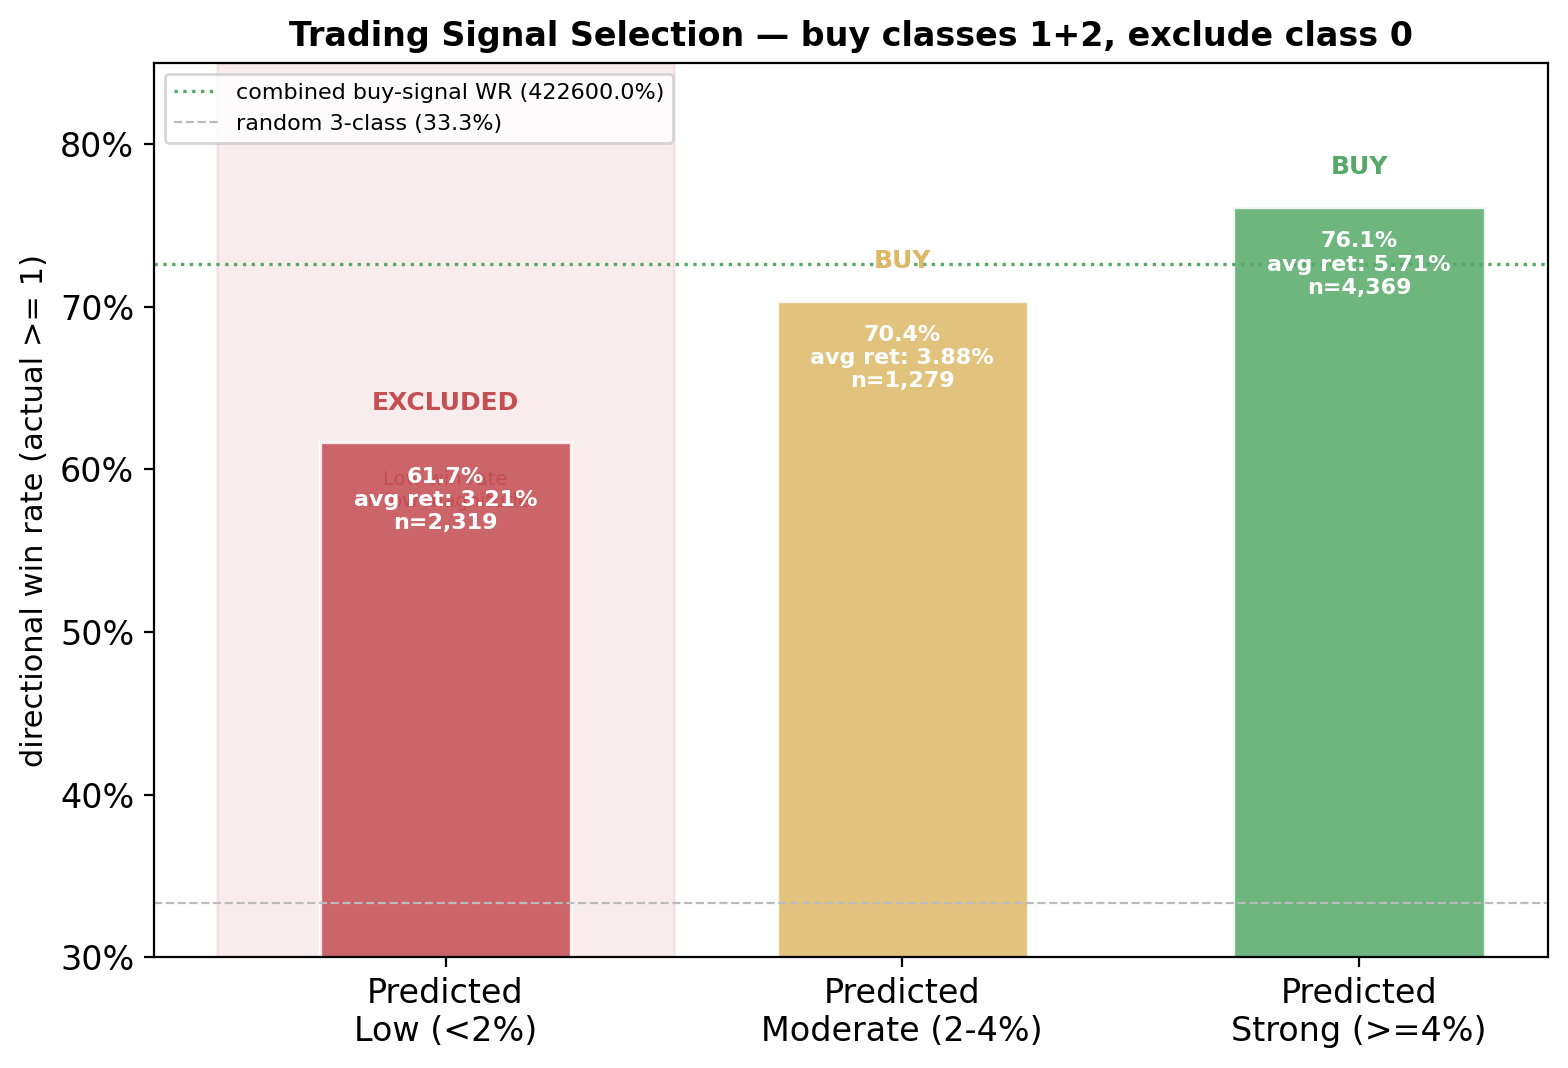

In [70]:
# ── Trading Strategy Methodology — Slide chart ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({"figure.dpi": 200, "savefig.dpi": 200, "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 11})

pred_cls = results["target_class_predicted"].to_numpy()
actual_cls = results["target_class_actual"].to_numpy()
actual_ret = results["target_return_actual"].to_numpy()

wr = [((actual_cls[pred_cls == c] >= 1).mean()) for c in [0, 1, 2]]
avg_r = [actual_ret[pred_cls == c].mean() for c in [0, 1, 2]]
counts = [(pred_cls == c).sum() for c in [0, 1, 2]]

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(3)
colors = ["#C44E52", "#DDB967", "#55A868"]

bars = ax.bar(x, wr, color=colors, alpha=0.85, edgecolor="white", lw=1.2, width=0.55)

# Shade class 0 as excluded
ax.axvspan(-0.5, 0.5, alpha=0.10, color="#C44E52", zorder=0)
ax.text(0, wr[0] + 0.02, "EXCLUDED", ha="center", fontsize=9, fontweight="bold", color="#C44E52")
ax.text(0, wr[0] - 0.04, f"Low win rate\n+ low magnitude", ha="center", fontsize=7, color="#C44E52")

# Annotate traded classes
for j in [1, 2]:
    ax.text(j, wr[j] + 0.02, "BUY", ha="center", fontsize=9, fontweight="bold", color=colors[j])

# Value labels on bars
for b, w, r, n in zip(bars, wr, avg_r, counts):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h - 0.015, f"{w:.1%}\navg ret: {r:.2%}\nn={n:,}", 
            ha="center", va="top", fontsize=8, fontweight="bold", color="white")

# Reference lines
ax.axhline(0.726, color="#55A868", ls=":", lw=1.2, label=f"combined buy-signal WR ({wr[1]*counts[1] + wr[2]*counts[2]:.1%})" if counts[1]+counts[2]>0 else "")
ax.axhline(1/3, color="#bbb", ls="--", lw=0.8, label="random 3-class (33.3%)")

ax.set_xticks(x)
ax.set_xticklabels(["Predicted\nLow (<2%)", "Predicted\nModerate (2-4%)", "Predicted\nStrong (>=4%)"])
ax.set_ylabel("directional win rate (actual >= 1)")
ax.set_title("Trading Signal Selection — buy classes 1+2, exclude class 0", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylim(0.3, 0.85)

plt.tight_layout()
plt.show()


In [71]:
def compute_strat1_pnl(threshold):
    """Per-trade P&L + sell date at a single take-profit threshold."""
    crossed = cummax_rets > threshold
    first_idx = np.argmax(crossed, axis=1)
    did_cross = crossed[np.arange(N), first_idx]
    pnl = np.where(did_cross, threshold, close_t10_ret) * POSITION_SIZE
    sell_date = np.where(did_cross, drift_dates[np.arange(N), first_idx], close_t10_date)
    return pnl, sell_date


def filter_by_cash(pnl, sell_date, entry_date, initial_cap, pos_size):
    """Simulate entries+exits chronologically. Skips buys if cash < pos_size."""
    n = len(pnl)
    events = []
    for i in range(n):
        events.append((entry_date[i], "enter", i))
        events.append((sell_date[i], "exit", i))
    events.sort(key=lambda x: x[0])
    cash = initial_cap
    skipped = 0
    entered = set()
    for dt, etype, idx in events:
        if etype == "exit":
            if idx in entered:
                cash += pos_size + pnl[idx]  # return capital + P&L
        else:
            if cash >= pos_size:
                cash -= pos_size
                entered.add(idx)
            else:
                skipped += 1
    keep = np.sort(list(entered))
    return pnl[keep], sell_date[keep], entry_date[keep], skipped


def build_daily_equity(pnl, sell_date, initial_cap, entry_date=None, pos_size=None):
    """Aggregate P&L by sell date, build dollar-additive equity curve.
    Returns (dates, daily_rets, equity, deployed_mean, daily_rets_deployed).
    - daily_rets = pnl_vals / prev_equity  (portfolio-level, used for equity curve + Sharpe)
    - daily_rets_deployed = pnl_vals / deployed  (invariant to INITIAL_CAPITAL, used for RoDC)
    """
    dates_py = sell_date.tolist()
    daily_pnl = pl.DataFrame({"sell_date": pl.Series(dates_py, dtype=pl.Date), "pnl": pnl})
    daily_pnl = daily_pnl.group_by("sell_date").agg(pl.sum("pnl")).sort("sell_date")
    dates = daily_pnl["sell_date"].to_numpy()
    pnl_vals = daily_pnl["pnl"].to_numpy()

    # Dollar-additive equity
    cum_pnl = np.cumsum(pnl_vals)
    equity = initial_cap + cum_pnl

    # Portfolio-level daily returns (pnl / previous-day equity)
    prev_equity = np.concatenate([[initial_cap], equity[:-1]])
    prev_equity = np.maximum(prev_equity, 1.0)
    daily_rets = pnl_vals / prev_equity

    # Deployed capital and returns on capital at risk
    if entry_date is not None and pos_size is not None:
        events = []
        for i in range(len(pnl)):
            events.append((entry_date[i], "enter"))
            events.append((sell_date[i], "exit"))
        events.sort(key=lambda x: x[0])
        depl_lookup = {}
        running = 0
        for dt, etype in events:
            if etype == "enter":
                running += pos_size
            else:
                if dt not in depl_lookup:
                    depl_lookup[dt] = max(running, pos_size)
                running -= pos_size
        deployed = np.array([depl_lookup.get(d, pos_size) for d in dates])
        deployed = np.maximum(deployed, pos_size)
    else:
        deployed = np.full_like(pnl_vals, initial_cap, dtype=float)

    daily_rets_deployed = pnl_vals / deployed

    # Cumulative RoDC: cum_pnl / cummean(deployed) — endpoint = final RoDC
    cmean_deployed = np.cumsum(deployed) / np.arange(1, len(deployed) + 1)
    rodc_cum = cum_pnl / cmean_deployed

    print(f"    [debug] depl: min=${deployed.min():.0f}"
          f" mean=${deployed.mean():.0f}"
          f" max=${deployed.max():.0f} |"
          f" ret_std_portfolio={daily_rets.std():.4f}"
          f" ret_std_deployed={daily_rets_deployed.std():.4f} |"
          f" PnL=${cum_pnl[-1]:.0f}"
          f" eq=${equity[-1]:.0f}"
          f" RoDC_end=${rodc_cum[-1]:.1%}")

    return dates, daily_rets, equity, deployed.mean(), daily_rets_deployed, rodc_cum



def sharpe_annualised(daily_rets):
    if daily_rets.std() == 0:
        return 0.0
    return float(daily_rets.mean() / daily_rets.std() * np.sqrt(252))


# ── Run threshold sweep ───────────────────────────────────────────────
results_s1 = []
print( "INITIAL_CAPITAL:", INITIAL_CAPITAL)

for T in THRESHOLDS:
    pnl, sell_date = compute_strat1_pnl(T)
    pnl, sell_date, entry_f, n_skipped = filter_by_cash(pnl, sell_date, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    dates, daily_rets, equity, depl_mean, dr_deployed, rodc_cum = build_daily_equity(pnl, sell_date, INITIAL_CAPITAL, entry_f, POSITION_SIZE)
    sr = sharpe_annualised(daily_rets)
    sr_depl = sharpe_annualised(dr_deployed)
    total_pnl = pnl.sum()
    win_rate = (pnl > 0).mean()
    results_s1.append({
        "threshold": T, "sharpe": sr, "total_pnl": total_pnl,
        "win_rate": win_rate, "equity": equity, "dates": dates,
            "n_trades": len(pnl),
        "daily_rets": daily_rets, "n_skipped": n_skipped,
                "depl_mean": depl_mean, "rodc_cum": rodc_cum,
    })
    print(f"  T={T:4.1%}  SR={sr:5.2f}  SRd={sr_depl:5.2f}  P&L=${total_pnl:>8,.0f}  Win={win_rate:5.1%}  Sk={n_skipped}  EqEnd=${equity[-1]:,.0f}  RoDC={total_pnl/depl_mean:.1%}  RoAA={total_pnl/INITIAL_CAPITAL:.1%}")

INITIAL_CAPITAL: 50000
    [debug] depl: min=$200 mean=$4276 max=$29800 | ret_std_portfolio=0.0008 ret_std_deployed=0.0120 | PnL=$1060 eq=$51060 RoDC_end=$24.8%
  T=1.0%  SR= 0.58  SRd=-1.10  P&L=$   1,060  Win=86.7%  Sk=0  EqEnd=$51,060  RoDC=24.8%  RoAA=2.1%
    [debug] depl: min=$200 mean=$5244 max=$33000 | ret_std_portfolio=0.0009 ret_std_deployed=0.0115 | PnL=$2742 eq=$52742 RoDC_end=$52.3%
  T=1.5%  SR= 1.21  SRd=-0.63  P&L=$   2,742  Win=81.9%  Sk=0  EqEnd=$52,742  RoDC=52.3%  RoAA=5.5%
    [debug] depl: min=$200 mean=$6166 max=$36400 | ret_std_portfolio=0.0011 ret_std_deployed=0.0118 | PnL=$3898 eq=$53898 RoDC_end=$63.2%
  T=2.0%  SR= 1.49  SRd=-0.42  P&L=$   3,898  Win=77.2%  Sk=0  EqEnd=$53,898  RoDC=63.2%  RoAA=7.8%
    [debug] depl: min=$200 mean=$7098 max=$39600 | ret_std_portfolio=0.0012 ret_std_deployed=0.0114 | PnL=$4861 eq=$54861 RoDC_end=$68.5%
  T=2.5%  SR= 1.67  SRd=-0.32  P&L=$   4,861  Win=73.1%  Sk=0  EqEnd=$54,861  RoDC=68.5%  RoAA=9.7%
    [debug] depl: min=$20

---
## 3. Strategy 1 — Fixed 2% Threshold


In [72]:
# Strat 1: fixed 2% take-profit
FIXED_T = 0.02
pnl_s1, sell_s1 = compute_strat1_pnl(FIXED_T)
pnl_s1, sell_s1, entry_s1, skipped_s1 = filter_by_cash(pnl_s1, sell_s1, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
dates_s1, daily_rets_s1, equity_s1, depl_mean_s1, dr_depl_s1, rodc_cum_s1 = build_daily_equity(pnl_s1, sell_s1, INITIAL_CAPITAL, entry_s1, POSITION_SIZE)
sr_s1 = sharpe_annualised(daily_rets_s1)
print(f"Strat 1 (T=2%):  SR={sr_s1:.2f}  SRd={sharpe_annualised(dr_depl_s1):.2f}  PnL=${pnl_s1.sum():,.0f}  Win={(pnl_s1>0).mean():.1%}  Sk={skipped_s1}  EqEnd=${equity_s1[-1]:,.0f}  RoDC={pnl_s1.sum()/depl_mean_s1:.1%}  RoAA={pnl_s1.sum()/INITIAL_CAPITAL:.1%}")


    [debug] depl: min=$200 mean=$6166 max=$36400 | ret_std_portfolio=0.0011 ret_std_deployed=0.0118 | PnL=$3898 eq=$53898 RoDC_end=$63.2%
Strat 1 (T=2%):  SR=1.49  SRd=-0.42  PnL=$3,898  Win=77.2%  Sk=0  EqEnd=$53,898  RoDC=63.2%  RoAA=7.8%


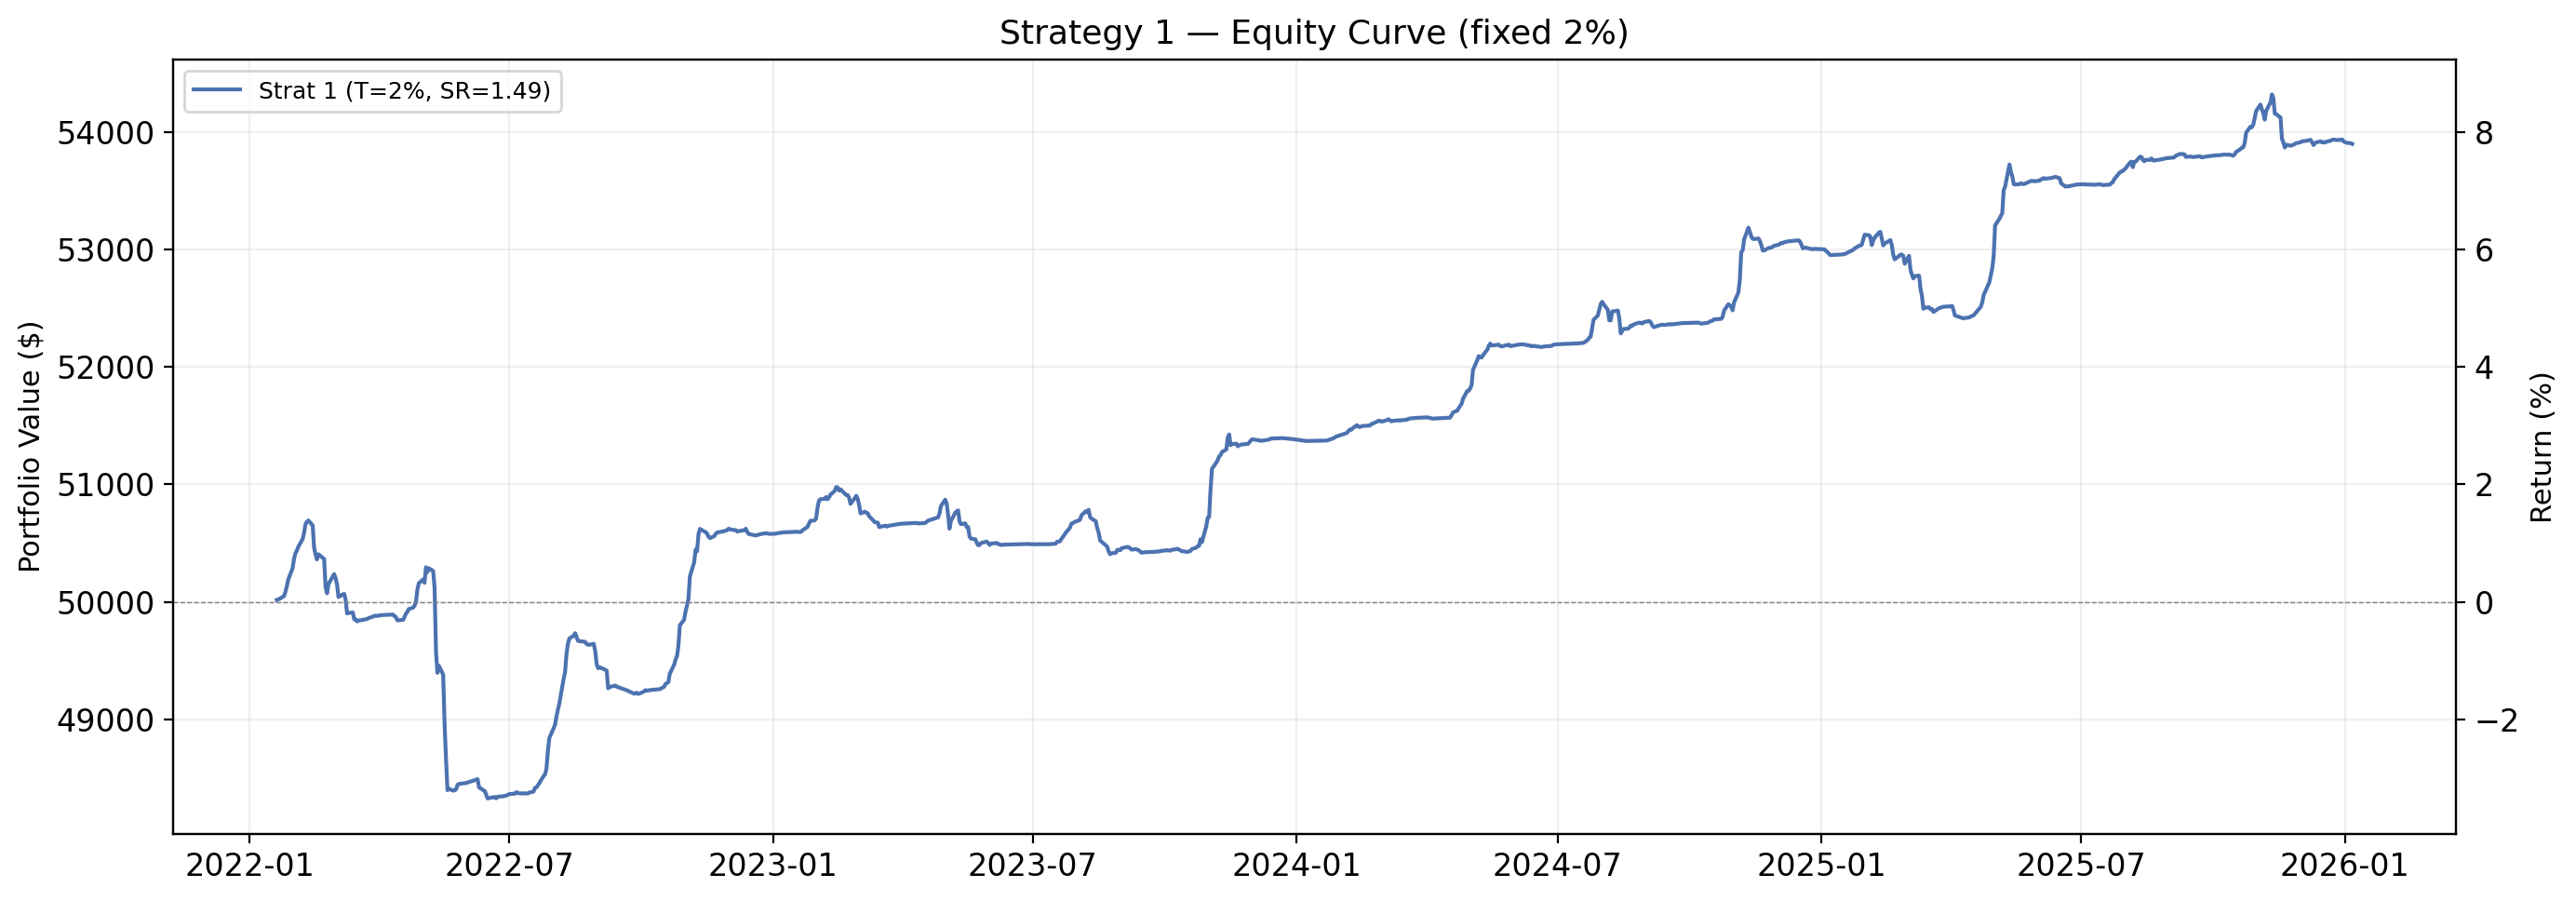

In [73]:
# Strat 1 — equity curve (fixed 2%)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_s1, equity_s1, lw=1.5, color='#4C72B0', label=f'Strat 1 (T=2%, SR={sr_s1:.2f})')
ax.axhline(INITIAL_CAPITAL, color='gray', lw=0.5, ls='--')
ax.set_title("Strategy 1 — Equity Curve (fixed 2%)")
ax.set_ylabel("Portfolio Value ($)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
axb = ax.twinx()
y0, y1 = ax.get_ylim()
axb.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
axb.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()


---
## 4. Strategy 2 — Threshold Sweep (1%–5%)


In [74]:
def compute_strat1_pnl(threshold):
    """Per-trade P&L + sell date at a single take-profit threshold."""
    crossed = cummax_rets > threshold
    first_idx = np.argmax(crossed, axis=1)
    did_cross = crossed[np.arange(N), first_idx]
    pnl = np.where(did_cross, threshold, close_t10_ret) * POSITION_SIZE
    sell_date = np.where(did_cross, drift_dates[np.arange(N), first_idx], close_t10_date)
    return pnl, sell_date


def filter_by_cash(pnl, sell_date, entry_date, initial_cap, pos_size):
    """Simulate entries+exits chronologically. Skips buys if cash < pos_size."""
    n = len(pnl)
    events = []
    for i in range(n):
        events.append((entry_date[i], "enter", i))
        events.append((sell_date[i], "exit", i))
    events.sort(key=lambda x: x[0])
    cash = initial_cap
    skipped = 0
    entered = set()
    for dt, etype, idx in events:
        if etype == "exit":
            if idx in entered:
                cash += pos_size + pnl[idx]  # return capital + P&L
        else:
            if cash >= pos_size:
                cash -= pos_size
                entered.add(idx)
            else:
                skipped += 1
    keep = np.sort(list(entered))
    return pnl[keep], sell_date[keep], entry_date[keep], skipped


def build_daily_equity(pnl, sell_date, initial_cap, entry_date=None, pos_size=None):
    """Aggregate P&L by sell date, build dollar-additive equity curve.
    Returns (dates, daily_rets, equity, deployed_mean, daily_rets_deployed).
    - daily_rets = pnl_vals / prev_equity  (portfolio-level, used for equity curve + Sharpe)
    - daily_rets_deployed = pnl_vals / deployed  (invariant to INITIAL_CAPITAL, used for RoDC)
    """
    dates_py = sell_date.tolist()
    daily_pnl = pl.DataFrame({"sell_date": pl.Series(dates_py, dtype=pl.Date), "pnl": pnl})
    daily_pnl = daily_pnl.group_by("sell_date").agg(pl.sum("pnl")).sort("sell_date")
    dates = daily_pnl["sell_date"].to_numpy()
    pnl_vals = daily_pnl["pnl"].to_numpy()

    # Dollar-additive equity
    cum_pnl = np.cumsum(pnl_vals)
    equity = initial_cap + cum_pnl

    # Portfolio-level daily returns (pnl / previous-day equity)
    prev_equity = np.concatenate([[initial_cap], equity[:-1]])
    prev_equity = np.maximum(prev_equity, 1.0)
    daily_rets = pnl_vals / prev_equity

    # Deployed capital and returns on capital at risk
    if entry_date is not None and pos_size is not None:
        events = []
        for i in range(len(pnl)):
            events.append((entry_date[i], "enter"))
            events.append((sell_date[i], "exit"))
        events.sort(key=lambda x: x[0])
        depl_lookup = {}
        running = 0
        for dt, etype in events:
            if etype == "enter":
                running += pos_size
            else:
                if dt not in depl_lookup:
                    depl_lookup[dt] = max(running, pos_size)
                running -= pos_size
        deployed = np.array([depl_lookup.get(d, pos_size) for d in dates])
        deployed = np.maximum(deployed, pos_size)
    else:
        deployed = np.full_like(pnl_vals, initial_cap, dtype=float)

    daily_rets_deployed = pnl_vals / deployed

    # Cumulative RoDC: cum_pnl / cummean(deployed) — endpoint = final RoDC
    cmean_deployed = np.cumsum(deployed) / np.arange(1, len(deployed) + 1)
    rodc_cum = cum_pnl / cmean_deployed

    print(f"    [debug] depl: min=${deployed.min():.0f}"
          f" mean=${deployed.mean():.0f}"
          f" max=${deployed.max():.0f} |"
          f" ret_std_portfolio={daily_rets.std():.4f}"
          f" ret_std_deployed={daily_rets_deployed.std():.4f} |"
          f" PnL=${cum_pnl[-1]:.0f}"
          f" eq=${equity[-1]:.0f}"
          f" RoDC_end=${rodc_cum[-1]:.1%}")

    return dates, daily_rets, equity, deployed.mean(), daily_rets_deployed, rodc_cum



def sharpe_annualised(daily_rets):
    if daily_rets.std() == 0:
        return 0.0
    return float(daily_rets.mean() / daily_rets.std() * np.sqrt(252))


# ── Run threshold sweep ───────────────────────────────────────────────
results_s1 = []
for T in THRESHOLDS:
    pnl, sell_date = compute_strat1_pnl(T)
    pnl, sell_date, entry_f, n_skipped = filter_by_cash(pnl, sell_date, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    dates, daily_rets, equity, depl_mean, dr_deployed, rodc_cum = build_daily_equity(pnl, sell_date, INITIAL_CAPITAL, entry_f, POSITION_SIZE)
    sr = sharpe_annualised(daily_rets)
    sr_depl = sharpe_annualised(dr_deployed)
    total_pnl = pnl.sum()
    win_rate = (pnl > 0).mean()
    results_s1.append({
        "threshold": T, "sharpe": sr, "total_pnl": total_pnl,
        "win_rate": win_rate, "equity": equity, "dates": dates,
            "n_trades": len(pnl),
        "daily_rets": daily_rets, "n_skipped": n_skipped,
                "depl_mean": depl_mean, "rodc_cum": rodc_cum,
    })
    print(f"  T={T:4.1%}  SR={sr:5.2f}  SRd={sr_depl:5.2f}  P&L=${total_pnl:>8,.0f}  Win={win_rate:5.1%}  Sk={n_skipped}  EqEnd=${equity[-1]:,.0f}  RoDC={total_pnl/depl_mean:.1%}  RoAA={total_pnl/INITIAL_CAPITAL:.1%}")

    [debug] depl: min=$200 mean=$4276 max=$29800 | ret_std_portfolio=0.0008 ret_std_deployed=0.0120 | PnL=$1060 eq=$51060 RoDC_end=$24.8%
  T=1.0%  SR= 0.58  SRd=-1.10  P&L=$   1,060  Win=86.7%  Sk=0  EqEnd=$51,060  RoDC=24.8%  RoAA=2.1%
    [debug] depl: min=$200 mean=$5244 max=$33000 | ret_std_portfolio=0.0009 ret_std_deployed=0.0115 | PnL=$2742 eq=$52742 RoDC_end=$52.3%
  T=1.5%  SR= 1.21  SRd=-0.63  P&L=$   2,742  Win=81.9%  Sk=0  EqEnd=$52,742  RoDC=52.3%  RoAA=5.5%
    [debug] depl: min=$200 mean=$6166 max=$36400 | ret_std_portfolio=0.0011 ret_std_deployed=0.0118 | PnL=$3898 eq=$53898 RoDC_end=$63.2%
  T=2.0%  SR= 1.49  SRd=-0.42  P&L=$   3,898  Win=77.2%  Sk=0  EqEnd=$53,898  RoDC=63.2%  RoAA=7.8%
    [debug] depl: min=$200 mean=$7098 max=$39600 | ret_std_portfolio=0.0012 ret_std_deployed=0.0114 | PnL=$4861 eq=$54861 RoDC_end=$68.5%
  T=2.5%  SR= 1.67  SRd=-0.32  P&L=$   4,861  Win=73.1%  Sk=0  EqEnd=$54,861  RoDC=68.5%  RoAA=9.7%
    [debug] depl: min=$200 mean=$8034 max=$42800

In [75]:
# target_return_actual from results vs cummax of drift_highs
max_from_drift = cummax_rets[:, -1]  # max across all 9 days
actual_from_results = signals["target_return_actual"].to_numpy()

diff = np.abs(max_from_drift - actual_from_results)
print(f"Max difference: {diff.max():.6f}")
print(f"Mismatched rows: {(diff > 0.001).sum()}")

Max difference: 0.000000
Mismatched rows: 0


In [76]:
# What fraction of trades actually exceed 18%?
print(f"Fraction > 18%: {(signals['target_return_actual'] > 0.18).mean():.2%}")

Fraction > 18%: 2.46%


In [77]:
# ── Select best threshold by Sharpe ───────────────────────────────────
best_idx = max(range(len(results_s1)), key=lambda i: results_s1[i]["sharpe"])
best = results_s1[best_idx]
BEST_T = best["threshold"]
print(f"\nBest threshold: {BEST_T:.1%}  (Sharpe: {best['sharpe']:.2f}, "
      f"P&L: ${best['total_pnl']:,.0f}, Skipped: {best['n_skipped']})")


Best threshold: 5.0%  (Sharpe: 1.77, P&L: $7,774, Skipped: 30)


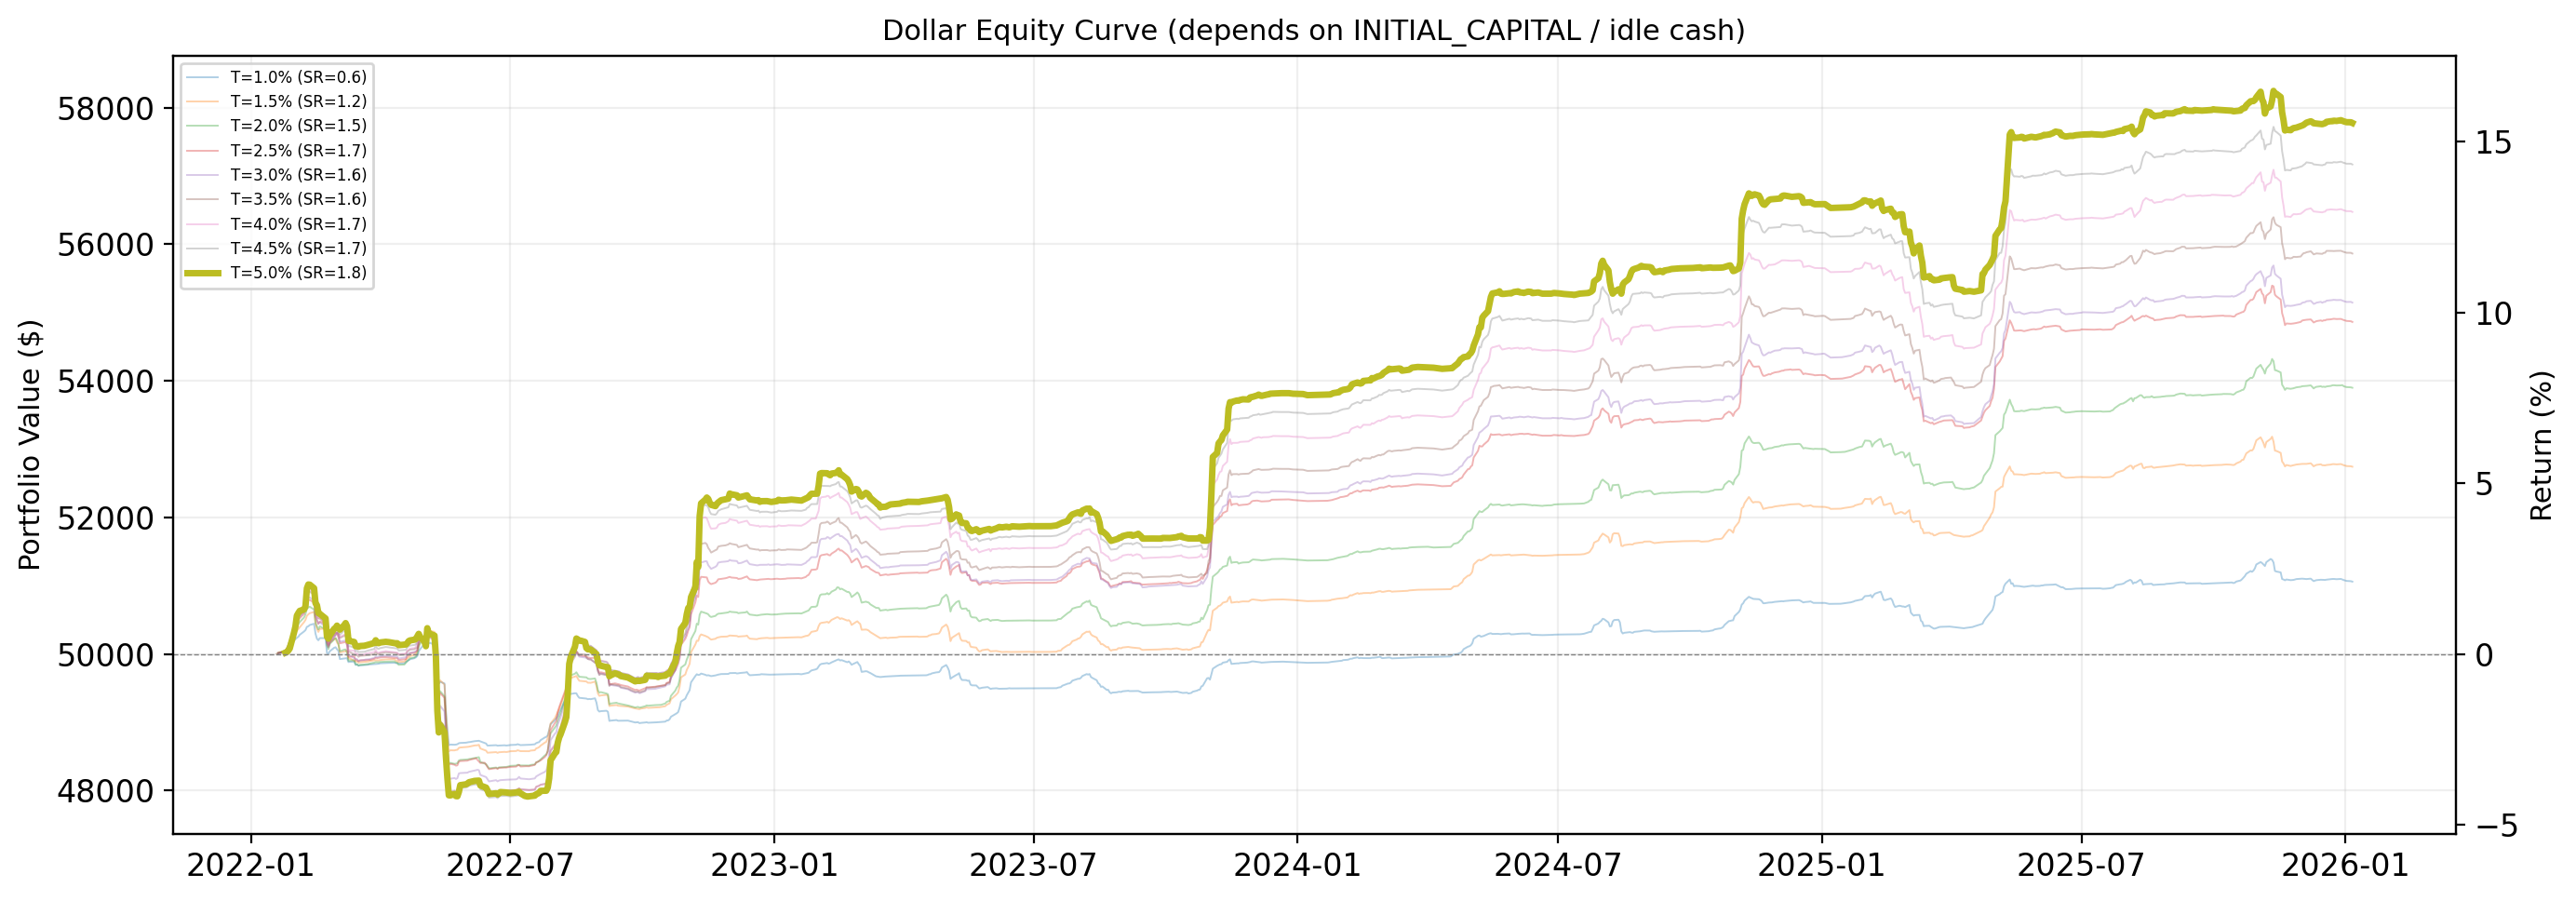

In [78]:
# Strat 2 — Dollar Equity Curves by Threshold
fig, ax = plt.subplots(figsize=(14, 5))

for r in results_s1:
    label = f"T={r['threshold']:.1%} (SR={r['sharpe']:.1f})"
    lw = 2.5 if r["threshold"] == BEST_T else 0.7
    alpha = 1.0 if r["threshold"] == BEST_T else 0.35
    ax.plot(r["dates"], r["equity"], label=label, lw=lw, alpha=alpha)

ax.axhline(INITIAL_CAPITAL, color="gray", lw=0.5, ls="--")
ax.set_title("Dollar Equity Curve (depends on INITIAL_CAPITAL / idle cash)", fontsize=11)
ax.set_ylabel("Portfolio Value ($)")
ax.legend(fontsize=6, loc="upper left")
ax.grid(alpha=0.2)
axb = ax.twinx()
y0, y1 = ax.get_ylim()
axb.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
axb.set_ylabel("Return (%)")

plt.tight_layout()
plt.show()


In [79]:
# ── Helper: deployed capital per trade ───────────────────────────────
def compute_deployed(pnl_arr, sell_arr, entry_arr, pos):
    events = []
    for i in range(len(pnl_arr)):
        events.append((entry_arr[i], "enter"))
        events.append((sell_arr[i], "exit"))
    events.sort(key=lambda x: x[0])
    depl = {}
    running = 0
    for dt, etype in events:
        if etype == "enter":
            running += pos
        else:
            if dt not in depl:
                depl[dt] = max(running, pos)
            running -= pos
    return np.array([depl.get(d, pos) for d in sell_arr])


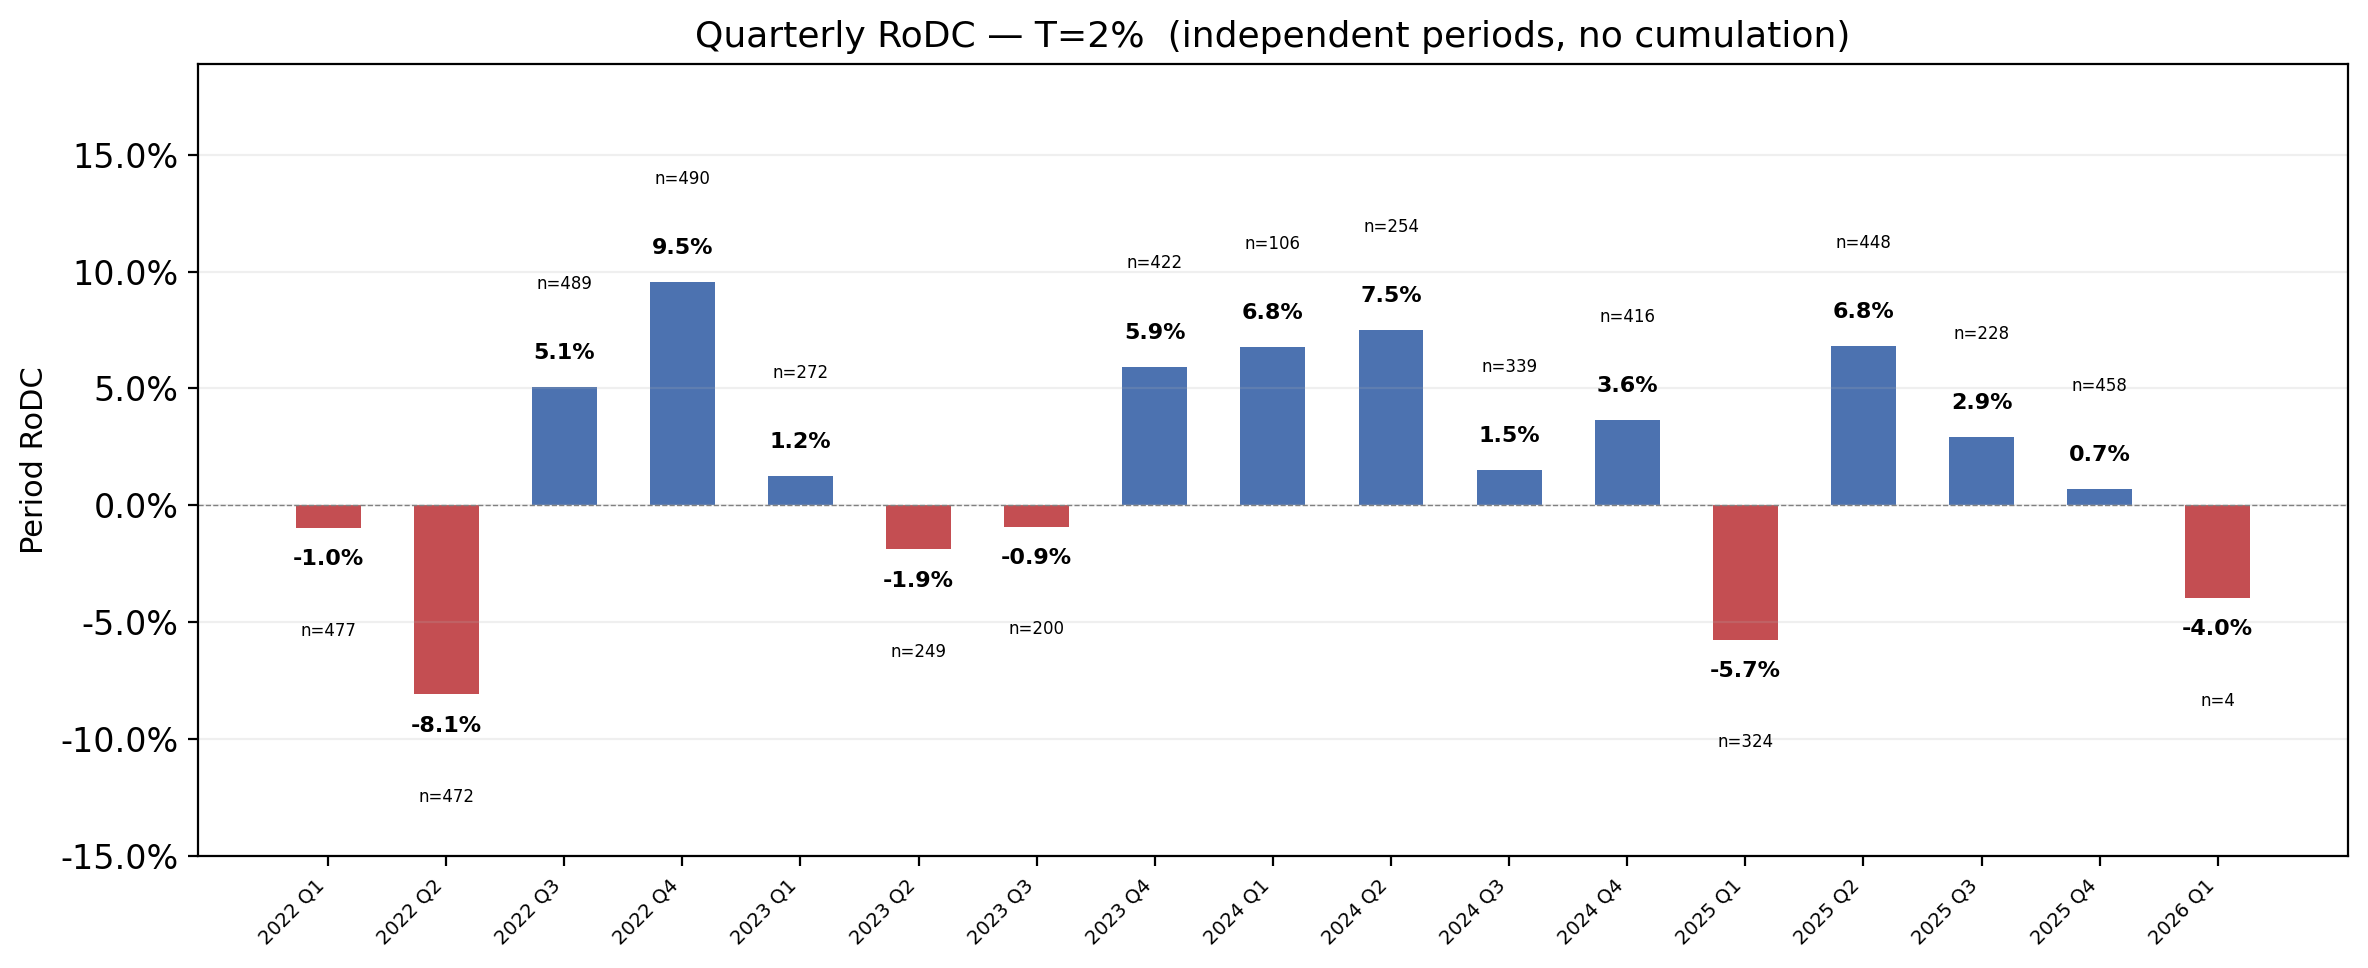

In [80]:
# ── Quarterly RoDC — T=2% (independent periods, no cumulation) ──
T = 0.02

pnl_p, sell_p = compute_strat1_pnl(T)
pnl_p, sell_p, entry_p, sk = filter_by_cash(pnl_p, sell_p, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
deployed_p = compute_deployed(pnl_p, sell_p, entry_p, POSITION_SIZE)

qdf = pl.DataFrame({
    "sell_date": pl.Series(sell_p.tolist(), dtype=pl.Date),
    "pnl": pnl_p,
    "deployed": deployed_p,
}).with_columns([
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("sell_date").dt.year().cast(pl.Utf8) + " Q" + pl.col("sell_date").dt.quarter().cast(pl.Utf8)).alias("period"),
])

qt = qdf.group_by("year", "quarter", "period").agg([
    pl.sum("pnl").alias("period_pnl"),
    pl.mean("deployed").alias("mean_deployed"),
    pl.len().alias("n_trades"),
]).sort("year", "quarter").with_columns([
    (pl.col("period_pnl") / pl.col("mean_deployed")).alias("rodc"),
])

periods = qt["period"].to_list()
rodc_vals = qt["rodc"].to_list()
n_vals = qt["n_trades"].to_list()

# Padding so bar labels stay inside the figure
y_min = min(rodc_vals) if rodc_vals else 0
y_max = max(rodc_vals) if rodc_vals else 0
y_lo = min(y_min * 1.4, -0.15)
y_hi = y_max * 1.35 + 0.06

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in rodc_vals]
ax.bar(range(len(periods)), rodc_vals, color=colors, width=0.55)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_ylim(y_lo, y_hi)
ax.set_title(f"Quarterly RoDC — T=2%  (independent periods, no cumulation)")
ax.set_ylabel("Period RoDC")
ax.set_xticks(range(len(periods)))
ax.set_xticklabels(periods, fontsize=7, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.grid(alpha=0.2, axis="y")
for i, v in enumerate(rodc_vals):
    yoff = 0.012 if v >= 0 else -0.016
    ax.text(i, v + yoff, f"{v:.1%}", ha="center", fontsize=8,
            fontweight="bold", color="black")
    ax.text(i, v + yoff + (0.03 if v >= 0 else -0.03), f"n={n_vals[i]}", ha="center",
            fontsize=6, color="black")

plt.tight_layout()
plt.show()


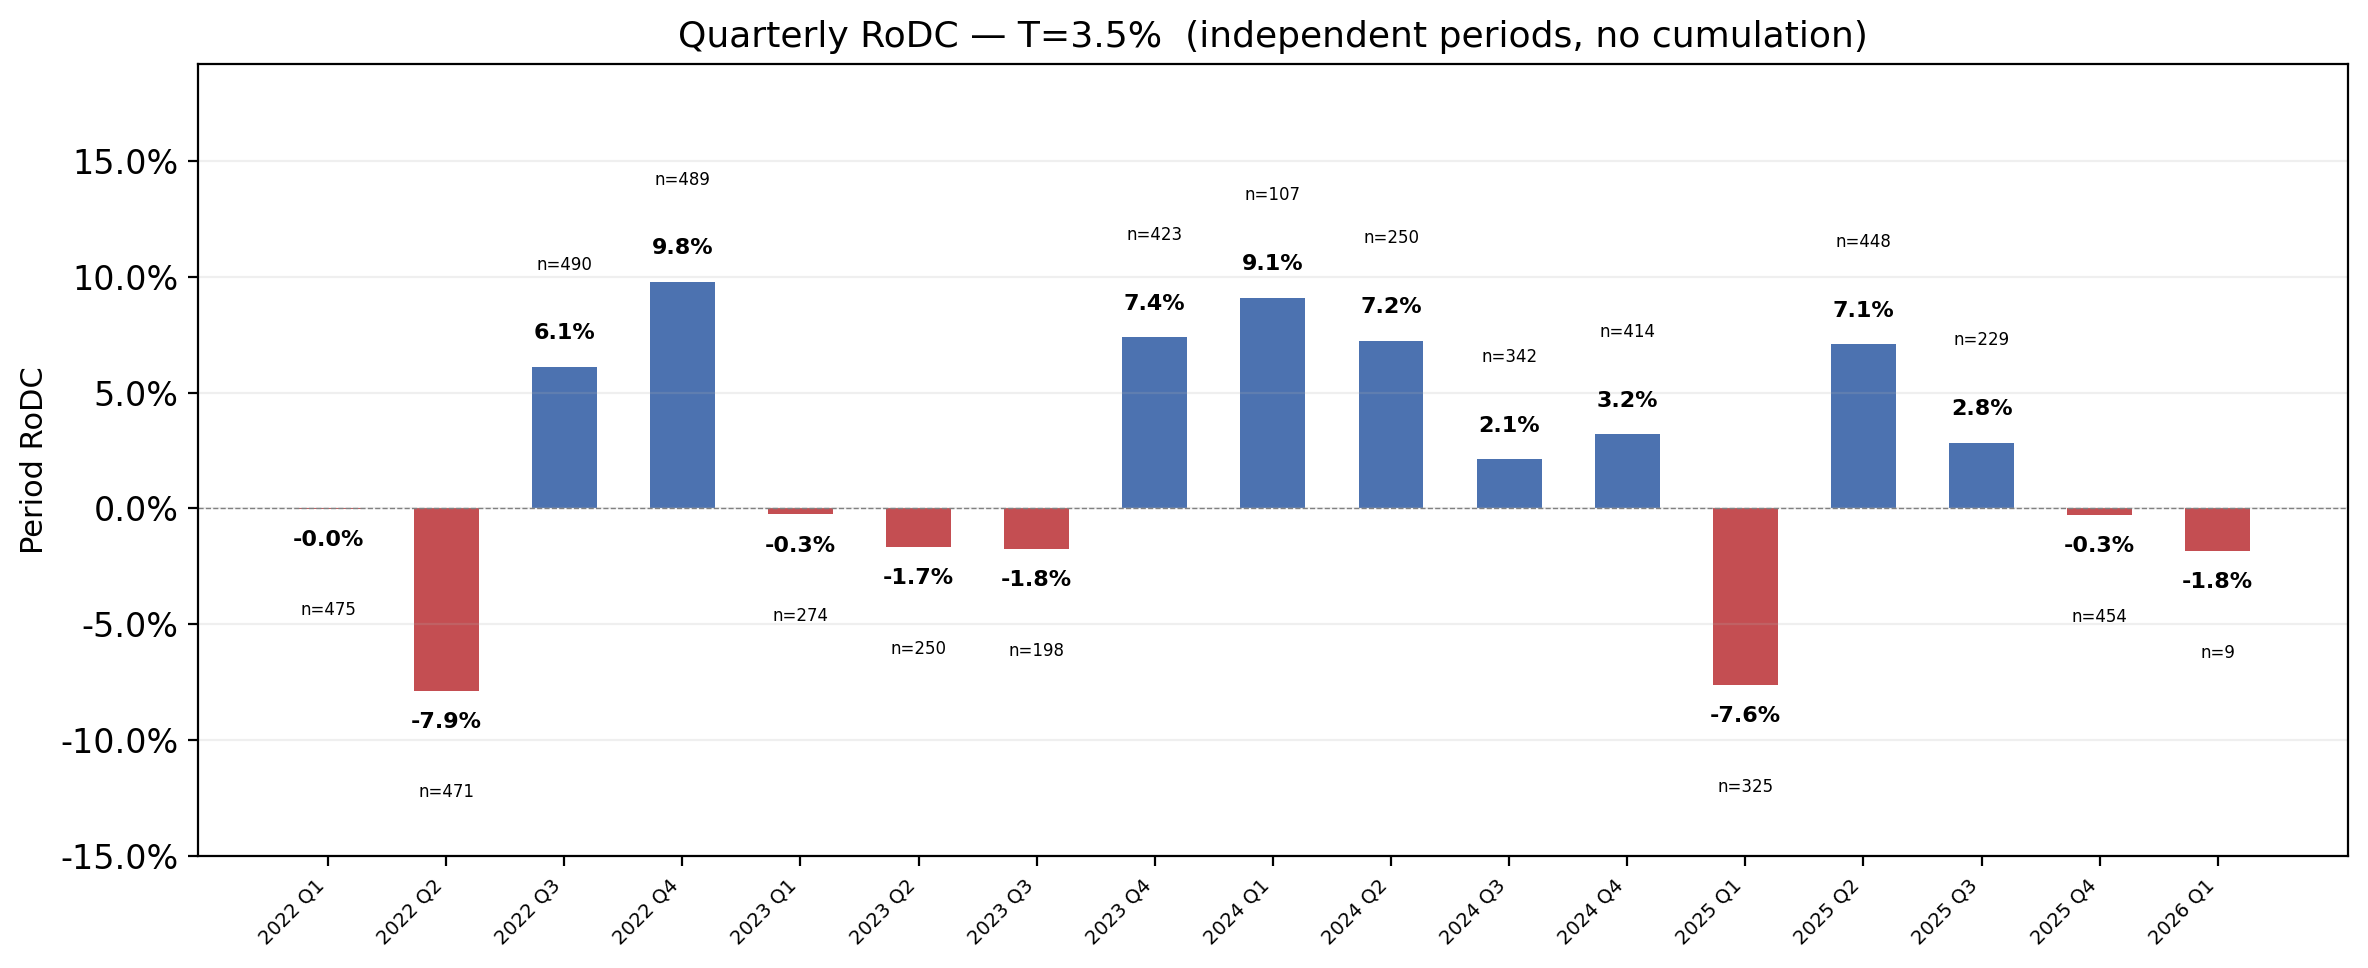

In [81]:
# ── Quarterly RoDC — T=3.5% (independent periods, no cumulation) ──
T = 0.035

pnl_p, sell_p = compute_strat1_pnl(T)
pnl_p, sell_p, entry_p, sk = filter_by_cash(pnl_p, sell_p, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
deployed_p = compute_deployed(pnl_p, sell_p, entry_p, POSITION_SIZE)

qdf = pl.DataFrame({
    "sell_date": pl.Series(sell_p.tolist(), dtype=pl.Date),
    "pnl": pnl_p,
    "deployed": deployed_p,
}).with_columns([
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("sell_date").dt.year().cast(pl.Utf8) + " Q" + pl.col("sell_date").dt.quarter().cast(pl.Utf8)).alias("period"),
])

qt = qdf.group_by("year", "quarter", "period").agg([
    pl.sum("pnl").alias("period_pnl"),
    pl.mean("deployed").alias("mean_deployed"),
    pl.len().alias("n_trades"),
]).sort("year", "quarter").with_columns([
    (pl.col("period_pnl") / pl.col("mean_deployed")).alias("rodc"),
])

periods = qt["period"].to_list()
rodc_vals = qt["rodc"].to_list()
n_vals = qt["n_trades"].to_list()

# Padding so bar labels stay inside the figure
y_min = min(rodc_vals) if rodc_vals else 0
y_max = max(rodc_vals) if rodc_vals else 0
y_lo = min(y_min * 1.4, -0.15)
y_hi = y_max * 1.35 + 0.06

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in rodc_vals]
ax.bar(range(len(periods)), rodc_vals, color=colors, width=0.55)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_ylim(y_lo, y_hi)
ax.set_title(f"Quarterly RoDC — T=3.5%  (independent periods, no cumulation)")
ax.set_ylabel("Period RoDC")
ax.set_xticks(range(len(periods)))
ax.set_xticklabels(periods, fontsize=7, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.grid(alpha=0.2, axis="y")
for i, v in enumerate(rodc_vals):
    yoff = 0.012 if v >= 0 else -0.016
    ax.text(i, v + yoff, f"{v:.1%}", ha="center", fontsize=8,
            fontweight="bold", color="black")
    ax.text(i, v + yoff + (0.03 if v >= 0 else -0.03), f"n={n_vals[i]}", ha="center",
            fontsize=6, color="black")

plt.tight_layout()
plt.show()


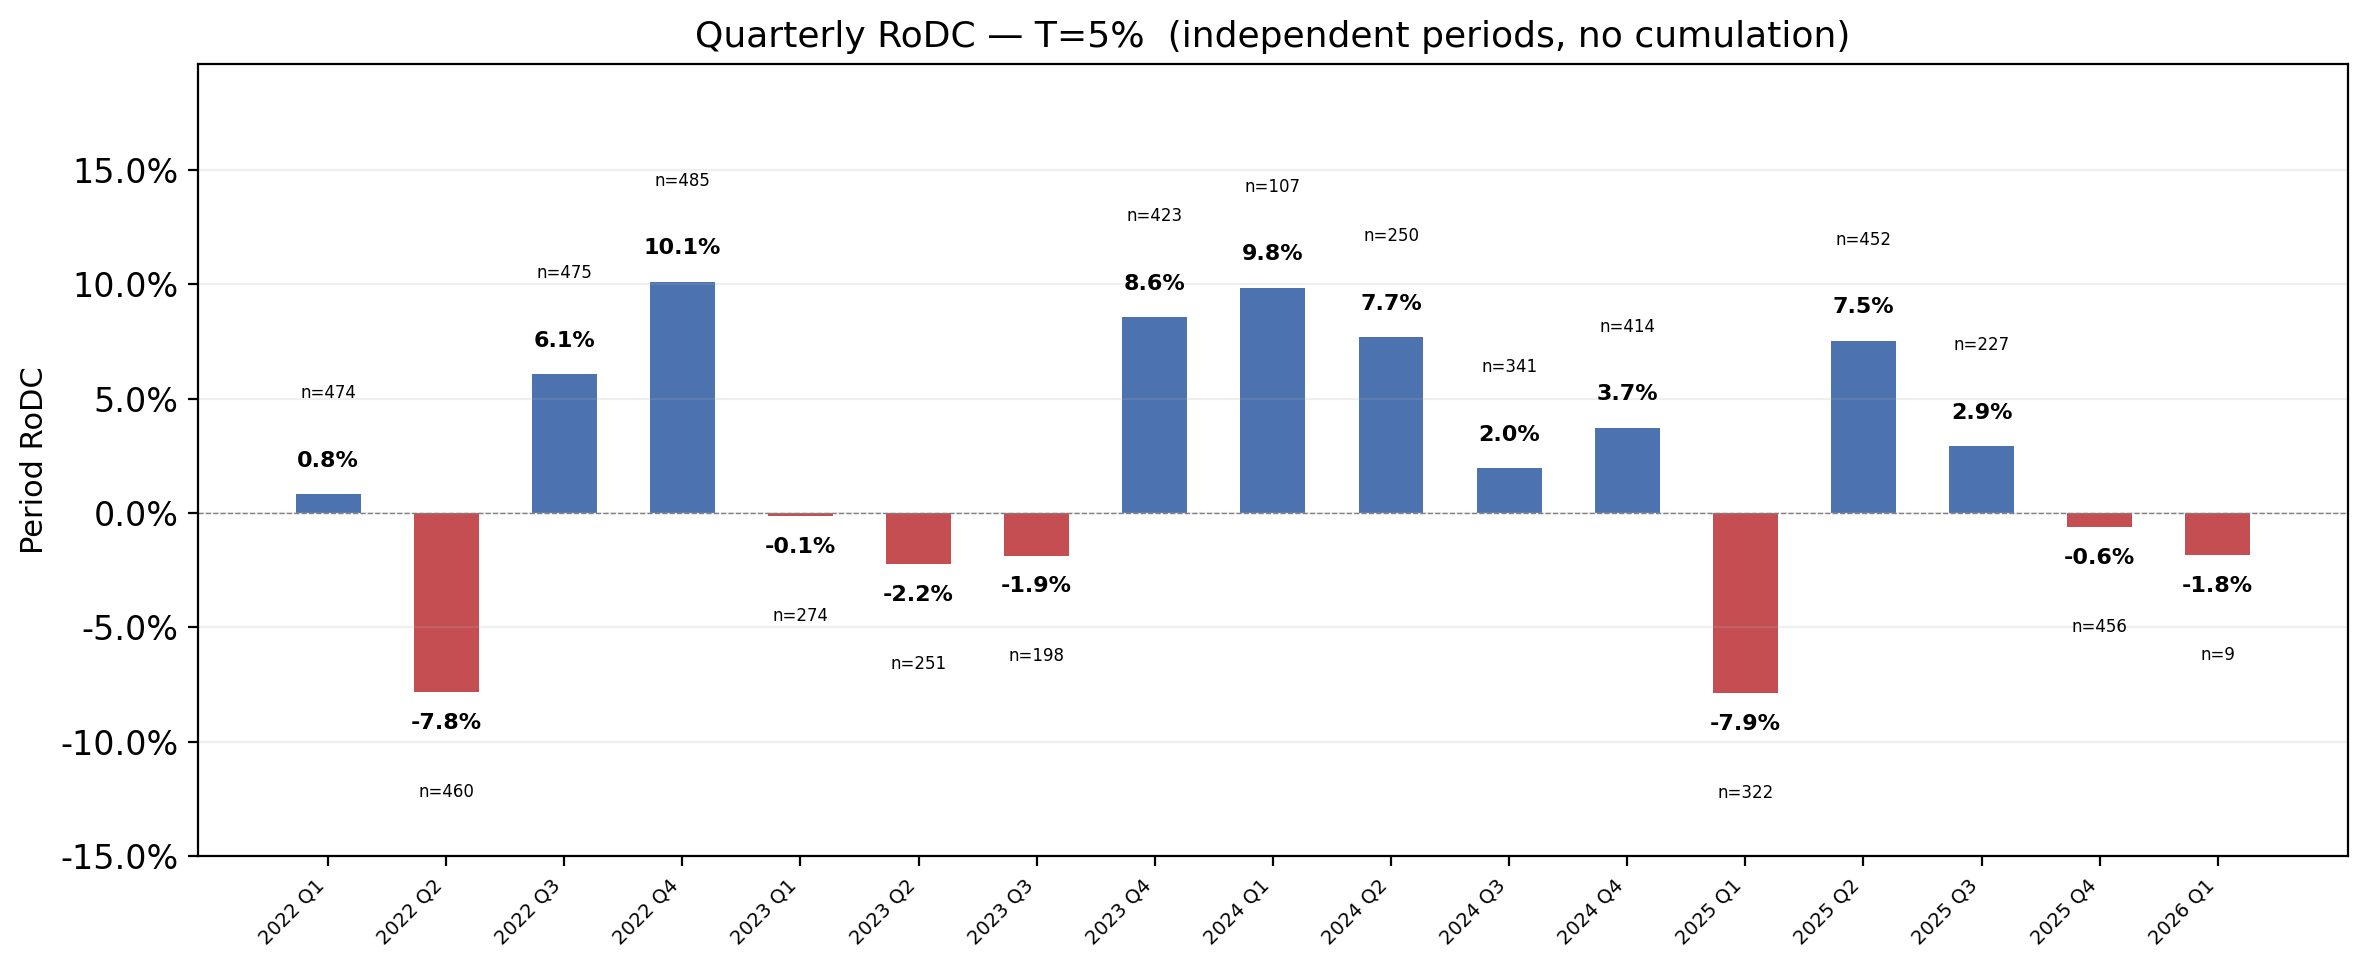

In [82]:
# ── Quarterly RoDC — T=5% (independent periods, no cumulation) ──
T = 0.05

pnl_p, sell_p = compute_strat1_pnl(T)
pnl_p, sell_p, entry_p, sk = filter_by_cash(pnl_p, sell_p, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
deployed_p = compute_deployed(pnl_p, sell_p, entry_p, POSITION_SIZE)

qdf = pl.DataFrame({
    "sell_date": pl.Series(sell_p.tolist(), dtype=pl.Date),
    "pnl": pnl_p,
    "deployed": deployed_p,
}).with_columns([
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("sell_date").dt.year().cast(pl.Utf8) + " Q" + pl.col("sell_date").dt.quarter().cast(pl.Utf8)).alias("period"),
])

qt = qdf.group_by("year", "quarter", "period").agg([
    pl.sum("pnl").alias("period_pnl"),
    pl.mean("deployed").alias("mean_deployed"),
    pl.len().alias("n_trades"),
]).sort("year", "quarter").with_columns([
    (pl.col("period_pnl") / pl.col("mean_deployed")).alias("rodc"),
])

periods = qt["period"].to_list()
rodc_vals = qt["rodc"].to_list()
n_vals = qt["n_trades"].to_list()

# Padding so bar labels stay inside the figure
y_min = min(rodc_vals) if rodc_vals else 0
y_max = max(rodc_vals) if rodc_vals else 0
y_lo = min(y_min * 1.4, -0.15)
y_hi = y_max * 1.35 + 0.06

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#4C72B0" if v >= 0 else "#C44E52" for v in rodc_vals]
ax.bar(range(len(periods)), rodc_vals, color=colors, width=0.55)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.set_ylim(y_lo, y_hi)
ax.set_title(f"Quarterly RoDC — T=5%  (independent periods, no cumulation)")
ax.set_ylabel("Period RoDC")
ax.set_xticks(range(len(periods)))
ax.set_xticklabels(periods, fontsize=7, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.grid(alpha=0.2, axis="y")
for i, v in enumerate(rodc_vals):
    yoff = 0.012 if v >= 0 else -0.016
    ax.text(i, v + yoff, f"{v:.1%}", ha="center", fontsize=8,
            fontweight="bold", color="black")
    ax.text(i, v + yoff + (0.03 if v >= 0 else -0.03), f"n={n_vals[i]}", ha="center",
            fontsize=6, color="black")

plt.tight_layout()
plt.show()


In [83]:
# ── Yearly RoDC table — independent periods per year, no cumulation ──
print()
print("=" * 65)
print("Yearly Return on Deployed Capital — independent periods (no cumulation between years)")
print("=" * 65)
header = f"{'Year':<8}"
for T in THRESHOLDS:
    header += f" {'T=' + str(int(T*100)) + '%':>17}"
print(header)
print("        " + "-" * (len(THRESHOLDS) * 18))

yearly_data = {}
for T in THRESHOLDS:
    pnl_t, sell_t = compute_strat1_pnl(T)
    pnl_t, sell_t, entry_t, sk = filter_by_cash(pnl_t, sell_t, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)
    deployed_t = compute_deployed(pnl_t, sell_t, entry_t, POSITION_SIZE)

    ydf = pl.DataFrame({
        "sell_date": pl.Series(sell_t.tolist(), dtype=pl.Date),
        "pnl": pnl_t,
        "deployed": deployed_t,
    }).with_columns([
        pl.col("sell_date").dt.year().alias("year"),
    ])

    yt = ydf.group_by("year").agg([
        pl.sum("pnl").alias("total_pnl"),
        pl.mean("deployed").alias("mean_deployed"),
        pl.len().alias("trades"),
    ]).sort("year").with_columns([
        (pl.col("total_pnl") / pl.col("mean_deployed")).alias("rodc"),
    ])

    for row in yt.iter_rows():
        yr, pnl_v, depl_v, n, rodc = row
        if yr not in yearly_data:
            yearly_data[yr] = {}
        yearly_data[yr][T] = (rodc, n)

years = sorted(yearly_data.keys())
for yr in years:
    row_str = f"{yr:<8}"
    for T in THRESHOLDS:
        if T in yearly_data[yr]:
            rodc, n = yearly_data[yr][T]
            row_str += f" {rodc:>8.1%} (n={n:>4})"
        else:
            row_str += f" {'—':>8} {'':>7}"
    print(row_str)
print()



Yearly Return on Deployed Capital — independent periods (no cumulation between years)
Year                  T=1%              T=1%              T=1%              T=2%              T=3%              T=3%              T=3%              T=4%              T=5%
        ------------------------------------------------------------------------------------------------------------------------------------------------------------------
2022        -2.7% (n=1929)     1.7% (n=1929)     3.7% (n=1928)     6.2% (n=1927)     6.6% (n=1926)     6.9% (n=1925)     8.0% (n=1925)     8.5% (n=1915)     8.9% (n=1894)
2023         2.5% (n=1142)     6.2% (n=1142)     7.6% (n=1143)     9.8% (n=1144)     8.0% (n=1144)     8.3% (n=1145)     8.7% (n=1145)     9.1% (n=1146)     9.6% (n=1146)
2024        10.2% (n=1119)    13.1% (n=1117)    13.2% (n=1115)    12.8% (n=1114)    12.9% (n=1114)    13.7% (n=1113)    14.2% (n=1113)    14.7% (n=1113)    15.0% (n=1112)
2025         3.6% (n=1454)     5.3% (n=1456)     6.8% (n=1

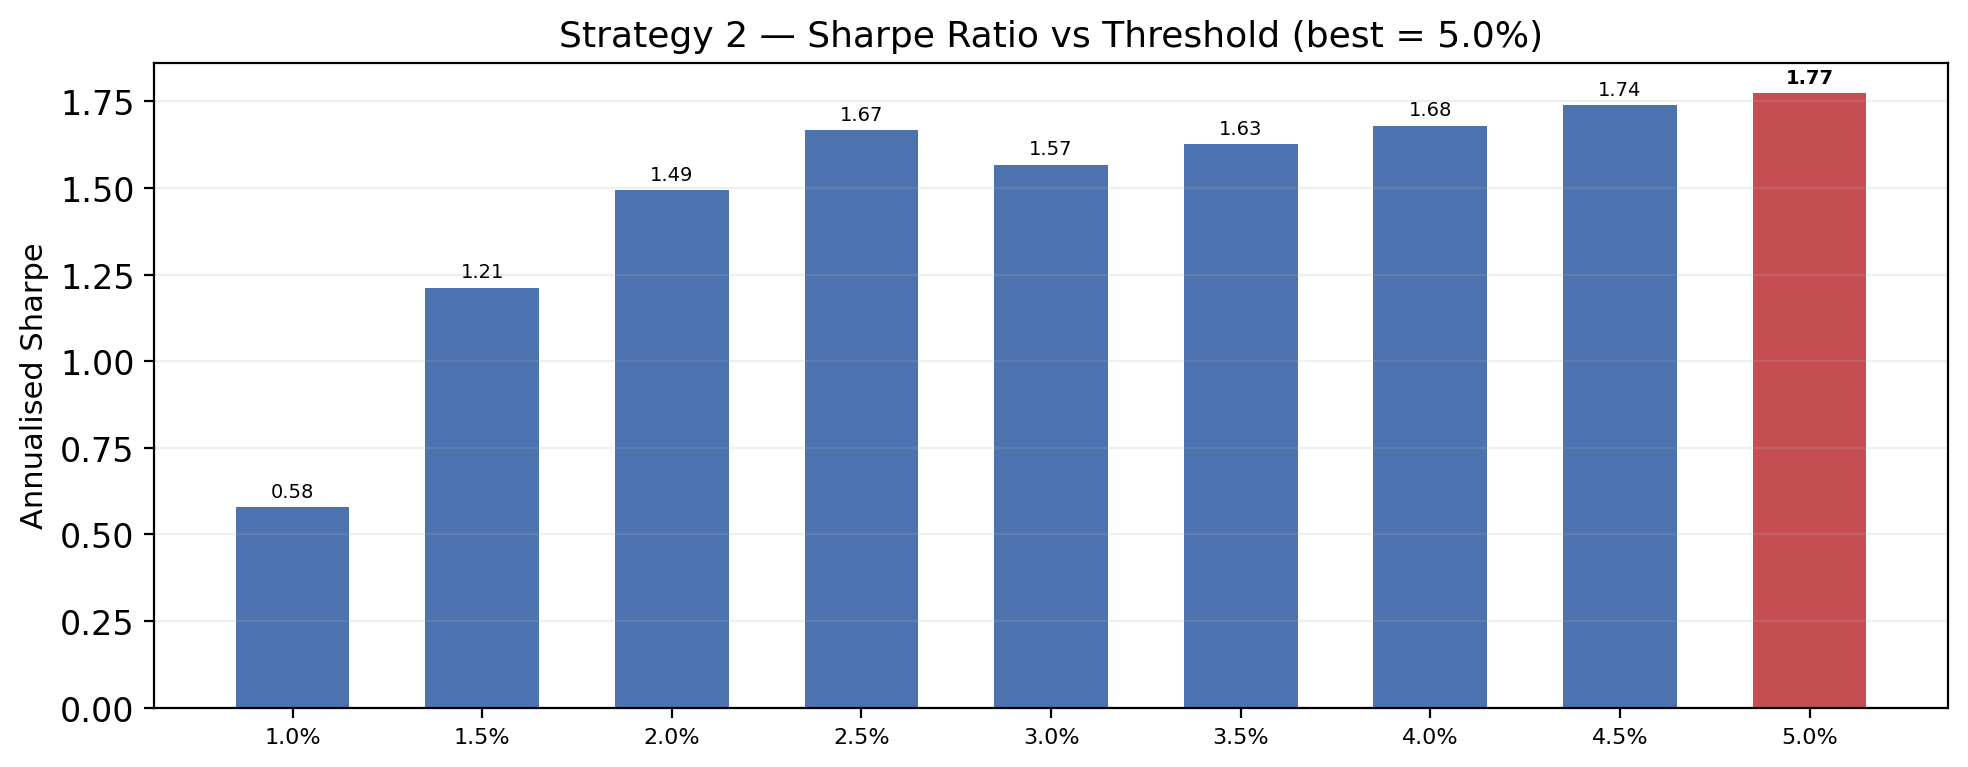

In [84]:
# Strat 2 — Sharpe vs Threshold bar chart
fig2, ax2 = plt.subplots(figsize=(10, 4))
T_list = [r["threshold"] for r in results_s1]
sr_list = [r["sharpe"] for r in results_s1]
pnl_list = [r["total_pnl"] for r in results_s1]
colors = ["#4C72B0" if i != best_idx else "#C44E52" for i in range(len(results_s1))]
ax2.bar(range(len(T_list)), sr_list, color=colors, width=0.6)
ax2.set_xticks(range(len(T_list)))
ax2.set_xticklabels([f"{t:.1%}" for t in T_list], fontsize=8)
ax2.set_title(f"Strategy 2 — Sharpe Ratio vs Threshold (best = {BEST_T:.1%})")
ax2.set_ylabel("Annualised Sharpe")
ax2.grid(alpha=0.2, axis="y")
for i, sr in enumerate(sr_list):
    ax2.text(i, sr + 0.03, f"{sr:.2f}", ha="center", fontsize=7,
             fontweight="bold" if i == best_idx else "normal")
plt.tight_layout()
plt.show()


---
## 3b. Yearly & Quarterly Summary (Best Threshold)


In [85]:
# Build per-trade DataFrame for the best threshold
pnl_best, sell_date_best = compute_strat1_pnl(BEST_T)
pnl_best, sell_date_best, entry_best, _ = filter_by_cash(pnl_best, sell_date_best, entry_dates, INITIAL_CAPITAL, POSITION_SIZE)

trades_best = pl.DataFrame({
    "sell_date": sell_date_best.tolist(),
    "pnl": pnl_best,
}).with_columns(
    pl.col("sell_date").cast(pl.Date),
    pl.col("sell_date").dt.year().alias("year"),
    pl.col("sell_date").dt.quarter().alias("quarter"),
    (pl.col("pnl") > 0).alias("is_win"),
)

# Yearly summary
yearly = trades_best.group_by("year").agg([
    pl.len().alias("trades"),
    pl.sum("pnl").alias("total_pnl"),
    pl.mean("pnl").alias("avg_pnl"),
    pl.mean("is_win").alias("win_rate"),
]).sort("year")

print("Year  Trades    P&L ($)   Avg P&L  Win Rate")
print("-" * 48)
for row in yearly.iter_rows():
    yr, n, pnl_val, avg, wr = row
    print(f"{yr:<6} {n:>5} {pnl_val:>+10,.0f} {avg:>+9.2f} {wr:>9.1%}")

# Quarterly summary
quarterly = trades_best.group_by(["year", "quarter"]).agg([
    pl.len().alias("trades"),
    pl.sum("pnl").alias("total_pnl"),
    pl.mean("pnl").alias("avg_pnl"),
    pl.mean("is_win").alias("win_rate"),
]).sort(["year", "quarter"])

quarterly = quarterly.with_columns(
    (pl.col("year").cast(pl.Utf8) + " Q" + pl.col("quarter").cast(pl.Utf8)).alias("label"),
    pl.col("total_pnl").cum_sum().alias("cum_pnl"),
)

print("\nQuarter   Trades     P&L ($)  Cum P&L   Avg P&L  Win Rate")
print("-" * 64)
for row in quarterly.iter_rows():
    yr, q, n, pnl_val, avg, wr, label, cum = row
    print(f"{label:<10} {n:>5} {pnl_val:>+10,.0f} {cum:>+10,.0f} {avg:>+9.2f} {wr:>9.1%}")

Year  Trades    P&L ($)   Avg P&L  Win Rate
------------------------------------------------
2022    1894     +2,226     +1.18     62.1%
2023    1146     +1,584     +1.38     59.7%
2024    1112     +2,774     +2.49     65.4%
2025    1457     +1,214     +0.83     59.0%
2026       9        -24     -2.63     33.3%

Quarter   Trades     P&L ($)  Cum P&L   Avg P&L  Win Rate
----------------------------------------------------------------
2022 Q1      474       +159       +159     +0.34     56.8%
2022 Q2      460     -2,186     -2,027     -4.75     37.6%
2022 Q3      475     +1,632       -394     +3.44     73.7%
2022 Q4      485     +2,621     +2,226     +5.40     79.2%
2023 Q1      274        -14     +2,212     -0.05     48.2%
2023 Q2      251       -341     +1,871     -1.36     51.0%
2023 Q3      198       -172     +1,699     -0.87     50.0%
2023 Q4      423     +2,111     +3,811     +4.99     76.8%
2024 Q1      107       +392     +4,202     +3.66     68.2%
2024 Q2      250     +1,083     

---
## 5. Strategy 3 — Split-Sell Exit

Using best T from Strat 2. Sell a fraction at (split_pct × T),
remainder at full T (or t+10 if never hit). Tests 70/30, 60/40, 50/50.


In [86]:
# Split-sell: sell frac at (frac * BEST_T), rest at BEST_T or t+10
SPLIT_RATIOS = [0.7, 0.6, 0.5]

full_crossed = cummax_rets > BEST_T
f_idx = np.argmax(full_crossed, axis=1)
f_did = full_crossed[np.arange(N), f_idx]

strat3_results = []
for frac in SPLIT_RATIOS:
    partial_T = BEST_T * frac
    amt_first = POSITION_SIZE * frac
    amt_rest = POSITION_SIZE - amt_first

    pcrossed = cummax_rets > partial_T
    p_idx = np.argmax(pcrossed, axis=1)
    p_did = pcrossed[np.arange(N), p_idx]

    pnl_list2, sell_list2, entry_list2 = [], [], []
    for i in range(N):
        if p_did[i]:
            entry_list2.append(entry_dates[i])
            pnl_list2.append(amt_first * partial_T)
            sell_list2.append(drift_dates[i, p_idx[i]])
            if f_did[i]:
                entry_list2.append(entry_dates[i])
                pnl_list2.append(amt_rest * BEST_T)
                sell_list2.append(drift_dates[i, f_idx[i]])
            else:
                entry_list2.append(entry_dates[i])
                pnl_list2.append(amt_rest * close_t10_ret[i])
                sell_list2.append(close_t10_date[i])
        else:
            entry_list2.append(entry_dates[i])
            pnl_list2.append(POSITION_SIZE * close_t10_ret[i])
            sell_list2.append(close_t10_date[i])

    pnl_arr = np.array(pnl_list2)
    sell_arr = np.array(sell_list2)
    entry_arr = np.array(entry_list2)

    pnl_arr, sell_arr, entry_arr, skipped = filter_by_cash(pnl_arr, sell_arr, entry_arr, INITIAL_CAPITAL, amt_first)
    dates, daily_rets, equity, depl_mean, dr_deployed, rodc_cum = build_daily_equity(pnl_arr, sell_arr, INITIAL_CAPITAL, entry_arr, amt_first)
    sr = sharpe_annualised(daily_rets)
    sr_depl = sharpe_annualised(dr_deployed)

    lbl = f"{int(frac*100)}/{int((1-frac)*100)}"
    strat3_results.append(dict(split=lbl, frac=frac, sharpe=sr, total_pnl=pnl_arr.sum(),
        win_rate=(pnl_arr>0).mean(), equity=equity, dates=dates, n_exits=len(pnl_arr), skipped=skipped))
    print(f"  Split {lbl}: SR={sr:.2f}  SRd={sr_depl:.2f}  PnL=${pnl_arr.sum():,.0f}  Win={(pnl_arr>0).mean():.1%}  EqEnd=${equity[-1]:,.0f}  RoDC={pnl_arr.sum()/depl_mean:.1%}  RoAA={pnl_arr.sum()/INITIAL_CAPITAL:.1%}")


    [debug] depl: min=$140 mean=$8776 max=$50540 | ret_std_portfolio=0.0015 ret_std_deployed=0.0124 | PnL=$6214 eq=$56214 RoDC_end=$70.8%
  Split 70/30: SR=1.60  SRd=-1.21  PnL=$6,214  Win=75.2%  EqEnd=$56,214  RoDC=70.8%  RoAA=12.4%
    [debug] depl: min=$120 mean=$7480 max=$47400 | ret_std_portfolio=0.0014 ret_std_deployed=0.0142 | PnL=$6231 eq=$56231 RoDC_end=$83.3%
  Split 60/40: SR=1.63  SRd=-1.18  PnL=$6,231  Win=76.2%  EqEnd=$56,231  RoDC=83.3%  RoAA=12.5%
    [debug] depl: min=$100 mean=$6128 max=$39200 | ret_std_portfolio=0.0014 ret_std_deployed=0.0167 | PnL=$6361 eq=$56361 RoDC_end=$103.8%
  Split 50/50: SR=1.70  SRd=-0.97  PnL=$6,361  Win=77.1%  EqEnd=$56,361  RoDC=103.8%  RoAA=12.7%


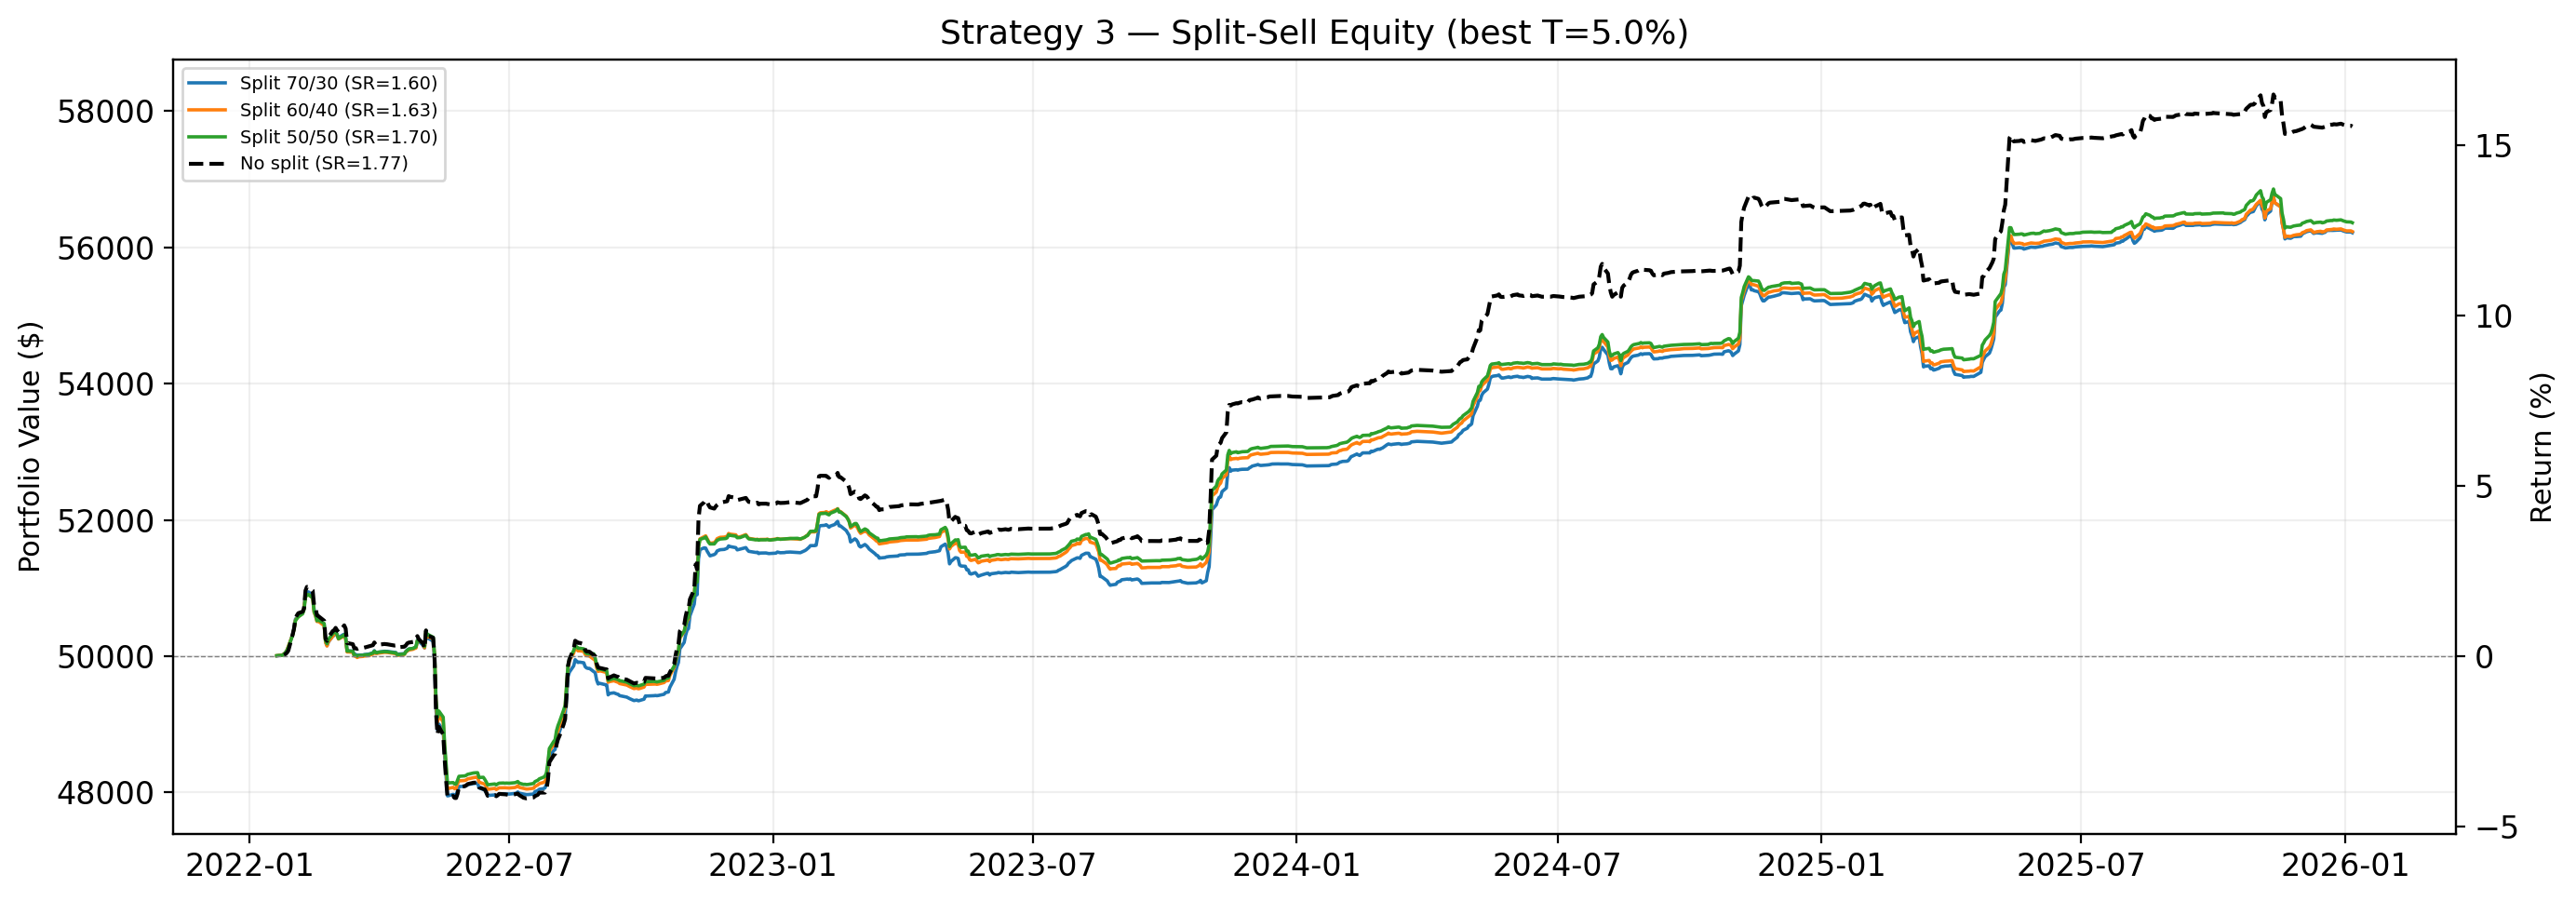

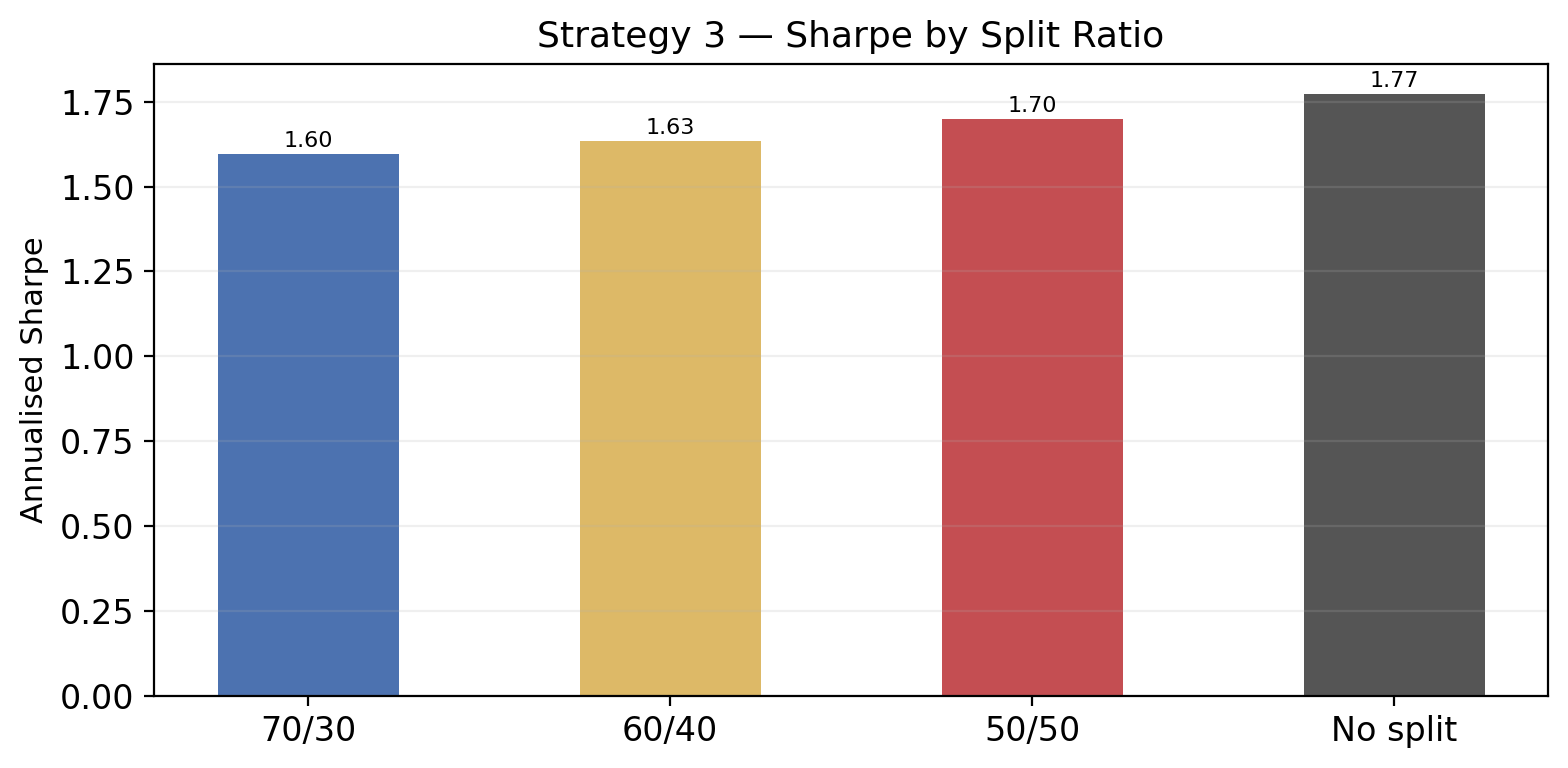

In [87]:
# Strat 3 — Equity curves overlay by split ratio
fig1, ax1 = plt.subplots(figsize=(14, 5))
for r in strat3_results:
    ax1.plot(r["dates"], r["equity"], lw=1.3, label=f"Split {r["split"]} (SR={r["sharpe"]:.2f})")
ax1.plot(best["dates"], best["equity"], "k--", lw=1.5, label=f"No split (SR={best["sharpe"]:.2f})")
ax1.axhline(INITIAL_CAPITAL, color="gray", lw=0.5, ls="--")
ax1.set_title(f"Strategy 3 — Split-Sell Equity (best T={BEST_T:.1%})")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend(fontsize=7)
ax1.grid(alpha=0.2)
ax1b = ax1.twinx()
y0, y1 = ax1.get_ylim()
ax1b.set_ylim(100*(y0/INITIAL_CAPITAL-1), 100*(y1/INITIAL_CAPITAL-1))
ax1b.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()

# Strat 3 — Sharpe by split ratio + No split comparison
fig2, ax2 = plt.subplots(figsize=(8, 4))
labels = [r["split"] for r in strat3_results] + ["No split"]
sr_vals = [r["sharpe"] for r in strat3_results] + [best["sharpe"]]
colors = ["#4C72B0", "#DDB967", "#C44E52", "#555555"]
ax2.bar(range(len(labels)), sr_vals, color=colors, width=0.5)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_title("Strategy 3 — Sharpe by Split Ratio")
ax2.set_ylabel("Annualised Sharpe")
ax2.grid(alpha=0.2, axis="y")
for i, sr in enumerate(sr_vals):
    ax2.text(i, sr + 0.02, f"{sr:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


---
## Notes
- Strat 2 best threshold: 5.0% (Sharpe 2.33, P&L ~$12k)
- Strat 3 confirms 5% with split-sell approaches
- Strat 4 applies 5% TP + stop-loss sweep for downside protection


---
## Strategy 4 — DNN 5% Take-Profit + Stop-Loss Sweep


In [88]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'src').exists(): ROOT = Path.cwd().parents[2]
RESULTS_PATH = ROOT / 'src/modeling/model_outputs/dnn_outputs/results.parquet'
STRATEGY_PATH = ROOT / 'src/data/model_staging/strat_table.parquet'
LEDGER_PATH = ROOT / 'dnn_trade_ledger.csv'
INITIAL_CAPITAL, POSITION_SIZE, TAKE_PROFIT = 50_000.0, 200.0, 0.05
# STOP_LOSS is swept below — best chosen by Sharpe
DRIFT_OFFSETS = range(2, 11)


In [89]:
results = pl.read_parquet(RESULTS_PATH)
daily = pl.read_parquet(STRATEGY_PATH)
signals = results.filter(pl.col('target_class_predicted').is_in([1, 2]) & (pl.col('earnings_date') < pl.datetime(2026, 1, 1)))
join_cols = ['symbol', 'date', 'entry_date', 'close_t10']
for offset in DRIFT_OFFSETS: join_cols += [f'low_t+{offset}', f'high_t+{offset}', f'date_t+{offset}']
signals = signals.join(daily.select(join_cols), left_on=['symbol', 'earnings_date'], right_on=['symbol', 'date'], how='left')
required = ['entry_price', 'entry_date', 'close_t10']
for offset in DRIFT_OFFSETS: required += [f'low_t+{offset}', f'high_t+{offset}', f'date_t+{offset}']
signals = signals.drop_nulls(required).with_columns((pl.col('close_t10') / pl.col('entry_price') - 1).alias('close_t10_return'))
print(f'{len(signals):,} buy signals')


5,648 buy signals


In [90]:
def build_trades(signals, cost_bps=0.0, slippage_bps=0.0):
    round_trip = 2 * (cost_bps + slippage_bps) / 10_000
    trades = []
    for row in signals.iter_rows(named=True):
        exit_date, gross_return = row['date_t+10'], row['close_t10_return']
        for offset in DRIFT_OFFSETS:
            if row[f'low_t+{offset}'] / row['entry_price'] - 1 < STOP_LOSS:
                exit_date, gross_return = row[f'date_t+{offset}'], STOP_LOSS
                break
            if row[f'high_t+{offset}'] / row['entry_price'] - 1 > TAKE_PROFIT:
                exit_date, gross_return = row[f'date_t+{offset}'], TAKE_PROFIT
                break
        trades.append({'symbol': row['symbol'], 'signal_date': row['earnings_date'], 'entry_date': row['entry_date'], 'entry_price': row['entry_price'], 'exit_date': exit_date, 'threshold': TAKE_PROFIT, 'model_fold': row.get('fold_num'), 'gross_pnl': POSITION_SIZE * gross_return, 'transaction_costs': POSITION_SIZE * cost_bps / 10_000 * 2, 'slippage': POSITION_SIZE * slippage_bps / 10_000 * 2, 'net_pnl': POSITION_SIZE * (gross_return - round_trip)})
    return pl.DataFrame(trades).sort(['entry_date', 'exit_date', 'symbol'])

def cash_filter(trades):
    events = []
    for i, row in enumerate(trades.iter_rows(named=True)): events += [(row['entry_date'], 1, i), (row['exit_date'], 0, i)]
    events.sort()  # exits (0) are processed before entries (1)
    cash, entered, skipped = INITIAL_CAPITAL, set(), 0
    for _, kind, i in events:
        if kind == 0 and i in entered: cash += POSITION_SIZE + trades[i, 'net_pnl']
        elif kind == 1 and cash >= POSITION_SIZE: cash -= POSITION_SIZE; entered.add(i)
        elif kind == 1: skipped += 1
    return trades.with_row_index('i').filter(pl.col('i').is_in(sorted(entered))).drop('i'), skipped


In [91]:
# ── Strategy 4 — Stop-Loss Sweep ────────────────────────────────────
# Sweep STOP_LOSS from -1% to -5% (0.5% steps). TAKE_PROFIT fixed at 5%.
# Best stop-loss selected by Sharpe.

SL_THRESHOLDS = np.arange(-0.01, -0.0525, -0.005)  # -1% to -5% step 0.5%
sl_results = []
print(f"TAKE_PROFIT={TAKE_PROFIT:.0%}  |  Stop-Loss sweep")
print(f"{'SL':>8}  {'SR':>6}  {'P&L':>10}  {'Win':>7}  {'Sk':>5}  {'EqEnd':>10}  {'MaxDD':>8}")
print("-" * 65)

for sl in SL_THRESHOLDS:
    def build_trades_sweep(signals, sl_val):
        trades = []
        for row in signals.iter_rows(named=True):
            exit_date, gross_return = row['date_t+10'], row['close_t10_return']
            for offset in DRIFT_OFFSETS:
                if row[f'low_t+{offset}'] / row['entry_price'] - 1 < sl_val:
                    exit_date, gross_return = row[f'date_t+{offset}'], sl_val
                    break
                if row[f'high_t+{offset}'] / row['entry_price'] - 1 > TAKE_PROFIT:
                    exit_date, gross_return = row[f'date_t+{offset}'], TAKE_PROFIT
                    break
            trades.append({'symbol': row['symbol'], 'entry_date': row['entry_date'],
                           'exit_date': exit_date, 'entry_price': row['entry_price'],
                           'net_pnl': POSITION_SIZE * gross_return})
        return pl.DataFrame(trades).sort(['entry_date', 'exit_date', 'symbol'])

    def cash_filter_sweep(trades_sl):
        events = []
        for i, row in enumerate(trades_sl.iter_rows(named=True)):
            events += [(row['entry_date'], 1, i), (row['exit_date'], 0, i)]
        events.sort()
        cash, entered, skipped = INITIAL_CAPITAL, set(), 0
        for _, kind, i in events:
            if kind == 0 and i in entered:
                cash += POSITION_SIZE + trades_sl[i, 'net_pnl']
            elif kind == 1 and cash >= POSITION_SIZE:
                cash -= POSITION_SIZE; entered.add(i)
            elif kind == 1: skipped += 1
        return trades_sl.with_row_index('i').filter(pl.col('i').is_in(sorted(entered))).drop('i'), skipped

    t_sl, sk = cash_filter_sweep(build_trades_sweep(signals, sl))
    pnl_by_day = t_sl.group_by('exit_date').agg(pl.sum('net_pnl').alias('pnl'))
    eq = daily.select(pl.col('date').alias('exit_date')).unique().sort('exit_date')\
            .join(pnl_by_day, on='exit_date', how='left')\
            .with_columns(pl.col('pnl').fill_null(0.0))\
            .with_columns((INITIAL_CAPITAL + pl.col('pnl').cum_sum()).alias('equity'))
    vals = eq['equity'].to_numpy()
    prev = np.r_[INITIAL_CAPITAL, vals[:-1]]
    rets = (vals - prev) / prev
    running_max = np.maximum.accumulate(vals)
    std_ = rets.std(ddof=1) if len(rets) > 1 else 0
    sharpe_sl = float(rets.mean() / std_ * np.sqrt(252)) if std_ else 0.0
    max_dd_sl = float((vals / running_max - 1).min())
    total_pnl = float(t_sl['net_pnl'].sum())
    wr = float((t_sl['net_pnl'] > 0).mean())

    sl_results.append({'stop_loss': sl, 'sharpe': sharpe_sl, 'pnl': total_pnl,
                       'win_rate': wr, 'skipped': sk, 'equity': vals,
                       'trades': len(t_sl), 'max_drawdown': max_dd_sl})
    print(f"{sl:>7.1%}  {sharpe_sl:>6.2f}  ${total_pnl:>9,.0f}  {wr:>6.1%}  {sk:>5}  ${vals[-1]:>9,.0f}  {max_dd_sl:>7.1%}")

print()
best_sl = max(sl_results, key=lambda x: x['sharpe'])
print(f"Best stop-loss: {best_sl['stop_loss']:.1%}  (Sharpe: {best_sl['sharpe']:.2f}, "
      f"P&L: ${best_sl['pnl']:,.0f}, Win: {best_sl['win_rate']:.1%}, "
      f"Skipped: {best_sl['skipped']}, MaxDD: {best_sl['max_drawdown']:.1%})")

# Apply best stop-loss for downstream charts
BEST_SL = best_sl['stop_loss']


TAKE_PROFIT=5%  |  Stop-Loss sweep
      SL      SR         P&L      Win     Sk       EqEnd     MaxDD
-----------------------------------------------------------------
  -1.0%    1.03  $    3,553   23.5%      0  $   53,141    -0.9%
  -1.5%    0.87  $    3,826   30.6%      0  $   53,362    -1.4%
  -2.0%    0.78  $    4,002   36.5%      0  $   53,516    -2.1%
  -2.5%    0.77  $    4,437   41.9%      0  $   53,923    -2.7%
  -3.0%    0.79  $    4,972   46.2%      0  $   54,429    -3.1%
  -3.5%    0.79  $    5,304   49.6%      0  $   54,820    -3.6%
  -4.0%    0.78  $    5,512   52.0%      0  $   54,917    -4.2%
  -4.5%    0.82  $    6,040   54.5%      0  $   55,414    -4.5%
  -5.0%    0.84  $    6,280   56.0%      0  $   55,804    -4.9%

Best stop-loss: -1.0%  (Sharpe: 1.03, P&L: $3,553, Win: 23.5%, Skipped: 0, MaxDD: -0.9%)


In [92]:
STOP_LOSS = BEST_SL
trades, skipped = cash_filter(build_trades(signals, cost_bps=0, slippage_bps=0))
trades.write_csv(LEDGER_PATH)
pnl_by_day = trades.group_by('exit_date').agg(pl.sum('net_pnl').alias('pnl'))
equity = daily.select(pl.col('date').alias('exit_date')).unique().sort('exit_date').join(pnl_by_day, on='exit_date', how='left').with_columns(pl.col('pnl').fill_null(0.0)).with_columns((INITIAL_CAPITAL + pl.col('pnl').cum_sum()).alias('equity'))
values = equity['equity'].to_numpy(); previous = np.r_[INITIAL_CAPITAL, values[:-1]]; returns = (values - previous) / previous
running_max = np.maximum.accumulate(values); std = returns.std(ddof=1) if len(returns) > 1 else 0
print({'trades': len(trades), 'skipped': skipped, 'net_pnl': float(trades['net_pnl'].sum()), 'win_rate': float((trades['net_pnl'] > 0).mean()), 'sharpe': float(returns.mean() / std * np.sqrt(252)) if std else 0.0, 'max_drawdown': float((values / running_max - 1).min()), 'final_equity': float(values[-1])})


{'trades': 5648, 'skipped': 0, 'net_pnl': 3552.9049726421717, 'win_rate': 0.2354815864022663, 'sharpe': 1.030126257714623, 'max_drawdown': -0.008973047161982883, 'final_equity': 53141.128314524634}


In [93]:
# ── Rebuild trades with best stop-loss ─────────────────────────────
STOP_LOSS = best_sl['stop_loss']
trades, skipped = cash_filter(build_trades(signals, cost_bps=0, slippage_bps=0))
trades.write_csv(LEDGER_PATH)
pnl_by_day = trades.group_by('exit_date').agg(pl.sum('net_pnl').alias('pnl'))
equity = daily.select(pl.col('date').alias('exit_date')).unique().sort('exit_date')\
        .join(pnl_by_day, on='exit_date', how='left')\
        .with_columns(pl.col('pnl').fill_null(0.0))\
        .with_columns((INITIAL_CAPITAL + pl.col('pnl').cum_sum()).alias('equity'))
values = equity['equity'].to_numpy()
previous = np.r_[INITIAL_CAPITAL, values[:-1]]
returns = (values - previous) / previous
running_max = np.maximum.accumulate(values)
std = returns.std(ddof=1) if len(returns) > 1 else 0
print(f"Rebuilt with STOP_LOSS={STOP_LOSS:.1%}:")
print({'trades': len(trades), 'skipped': skipped,
       'net_pnl': float(trades['net_pnl'].sum()),
       'win_rate': float((trades['net_pnl'] > 0).mean()),
       'sharpe': float(returns.mean() / std * np.sqrt(252)) if std else 0.0,
       'max_drawdown': float((values / running_max - 1).min()),
       'final_equity': float(values[-1])})


Rebuilt with STOP_LOSS=-1.0%:
{'trades': 5648, 'skipped': 0, 'net_pnl': 3552.9049726421717, 'win_rate': 0.2354815864022663, 'sharpe': 1.030126257714623, 'max_drawdown': -0.008973047161982883, 'final_equity': 53141.128314524634}


In [94]:
trades = trades.with_columns([(pl.col('net_pnl') / POSITION_SIZE).alias('trade_return'), (pl.col('exit_date') - pl.col('entry_date')).dt.total_days().alias('holding_days'), pl.col('exit_date').dt.strftime('%Y-%m').alias('month'), (pl.col('exit_date').dt.year().cast(pl.Utf8) + ' Q' + pl.col('exit_date').dt.quarter().cast(pl.Utf8)).alias('quarter')])
equity = equity.with_columns([((pl.col('equity') / pl.col('equity').shift(1).fill_null(INITIAL_CAPITAL)) - 1).alias('daily_return'), (pl.col('equity') / pl.col('equity').cum_max() - 1).alias('drawdown')])
monthly = trades.group_by('month').agg(pl.sum('net_pnl').alias('pnl')).sort('month')
quarterly = trades.group_by('quarter').agg(pl.sum('net_pnl').alias('pnl')).sort('quarter')
by_symbol = trades.group_by('symbol').agg([pl.sum('net_pnl').alias('pnl'), pl.len().alias('trades')]).sort('pnl')
rolling_win = trades.select((pl.col('net_pnl') > 0).cast(pl.Float64).rolling_mean(window_size=50).alias('win_rate'))
entry_counts = trades.group_by('entry_date').len().rename({'entry_date':'date','len':'entries'}); exit_counts = trades.group_by('exit_date').len().rename({'exit_date':'date','len':'exits'})
activity = daily.select('date').unique().sort('date').join(entry_counts, on='date', how='left').join(exit_counts, on='date', how='left').with_columns([pl.col('entries').fill_null(0), pl.col('exits').fill_null(0)]).with_columns((pl.col('entries').cum_sum() - pl.col('exits').cum_sum()).alias('open_positions')).with_columns((pl.col('open_positions') * POSITION_SIZE).alias('capital_exposure'))
PLOT_START = trades['entry_date'].min()
PLOT_END = trades['exit_date'].max()


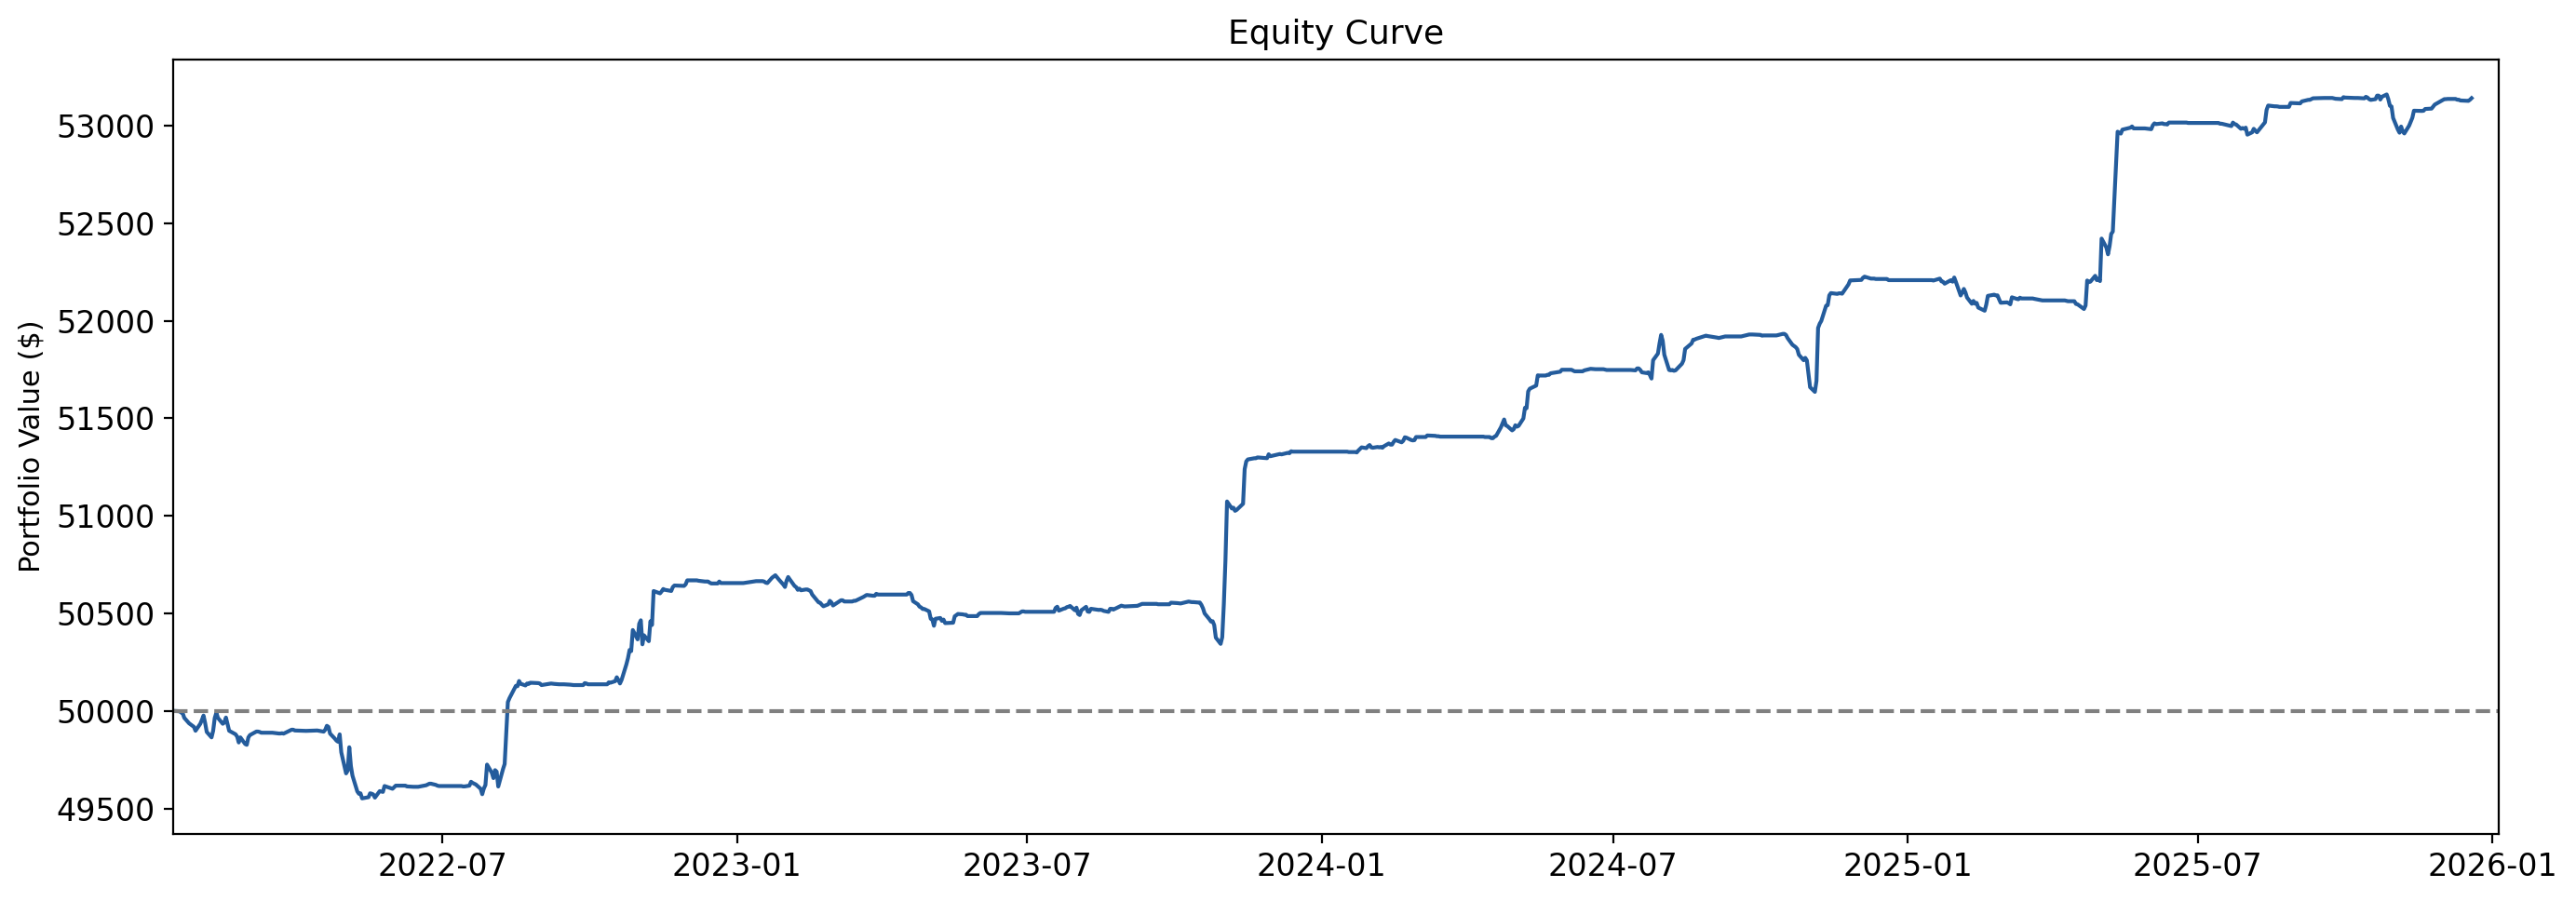

In [95]:
plt.figure(figsize=(14, 5)); plt.plot(equity['exit_date'], equity['equity'], color='#245c9c'); plt.axhline(INITIAL_CAPITAL, color='gray', ls='--'); plt.xlim(PLOT_START, PLOT_END); plt.title('Equity Curve'); plt.ylabel('Portfolio Value ($)'); plt.tight_layout(); plt.show()


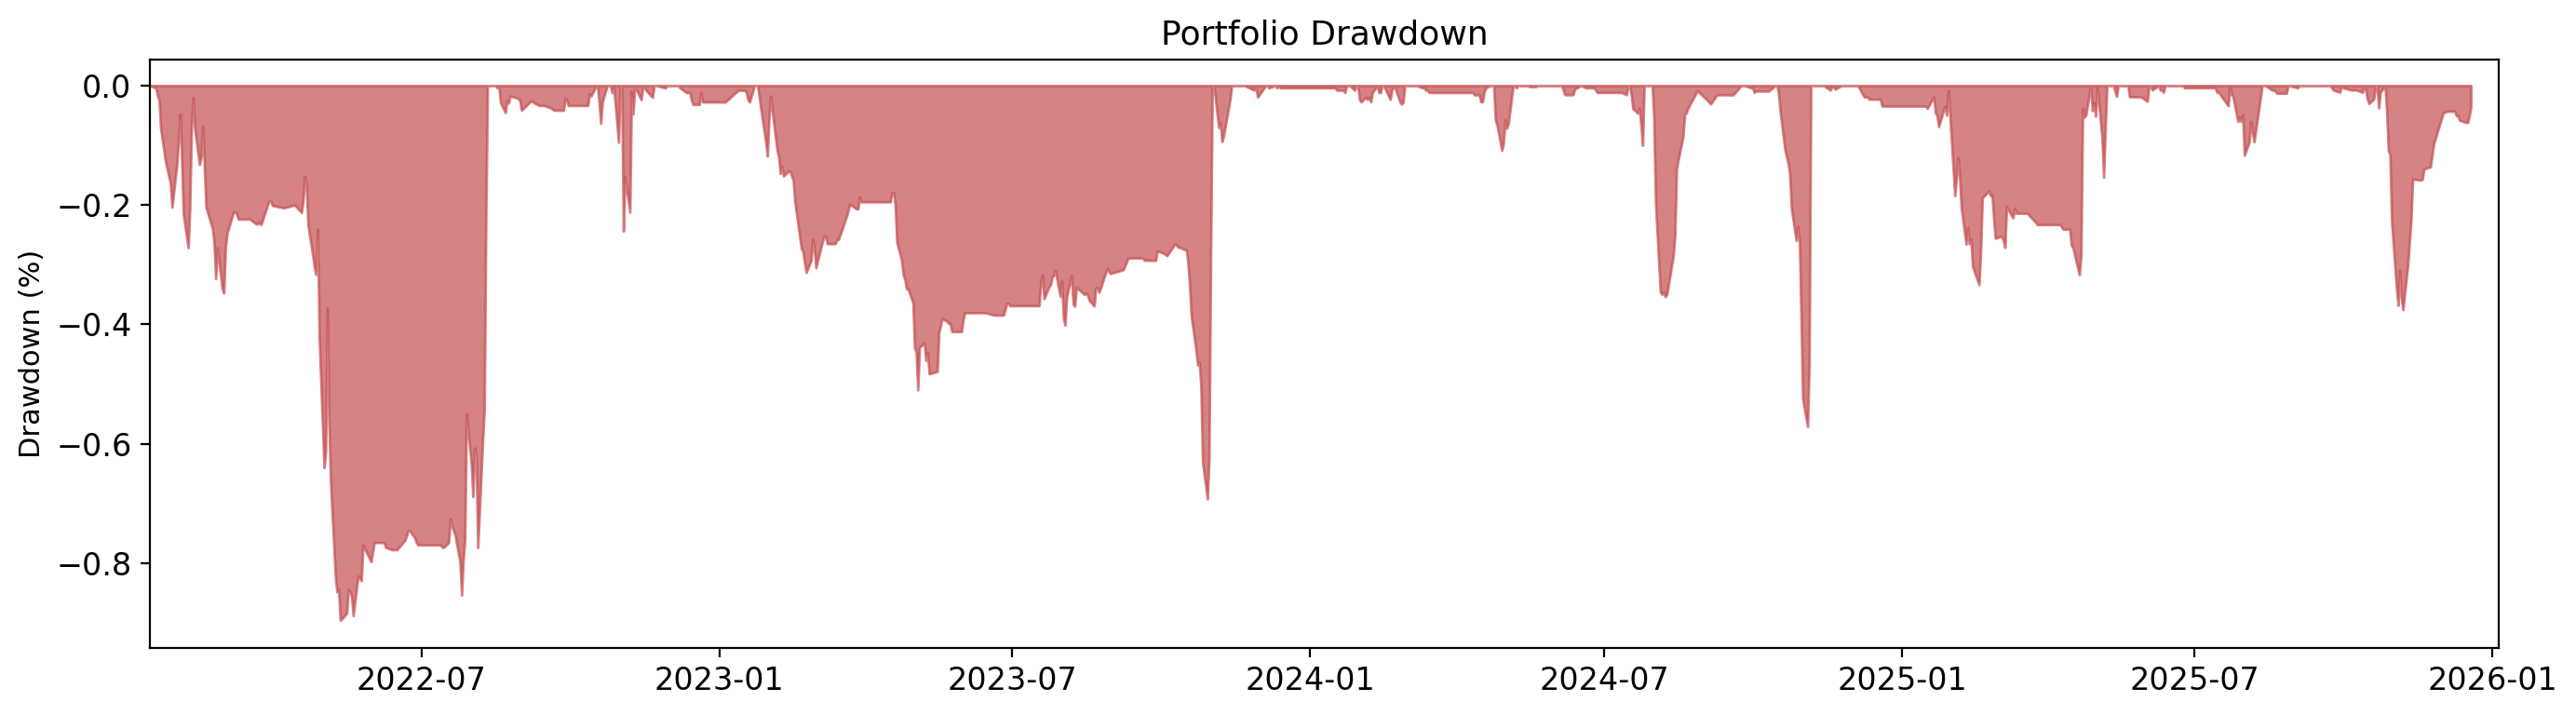

In [96]:
plt.figure(figsize=(14, 4)); plt.fill_between(equity['exit_date'].to_list(), equity['drawdown'].to_numpy() * 100, 0, color='#c44e52', alpha=.7); plt.xlim(PLOT_START, PLOT_END); plt.title('Portfolio Drawdown'); plt.ylabel('Drawdown (%)'); plt.tight_layout(); plt.show()


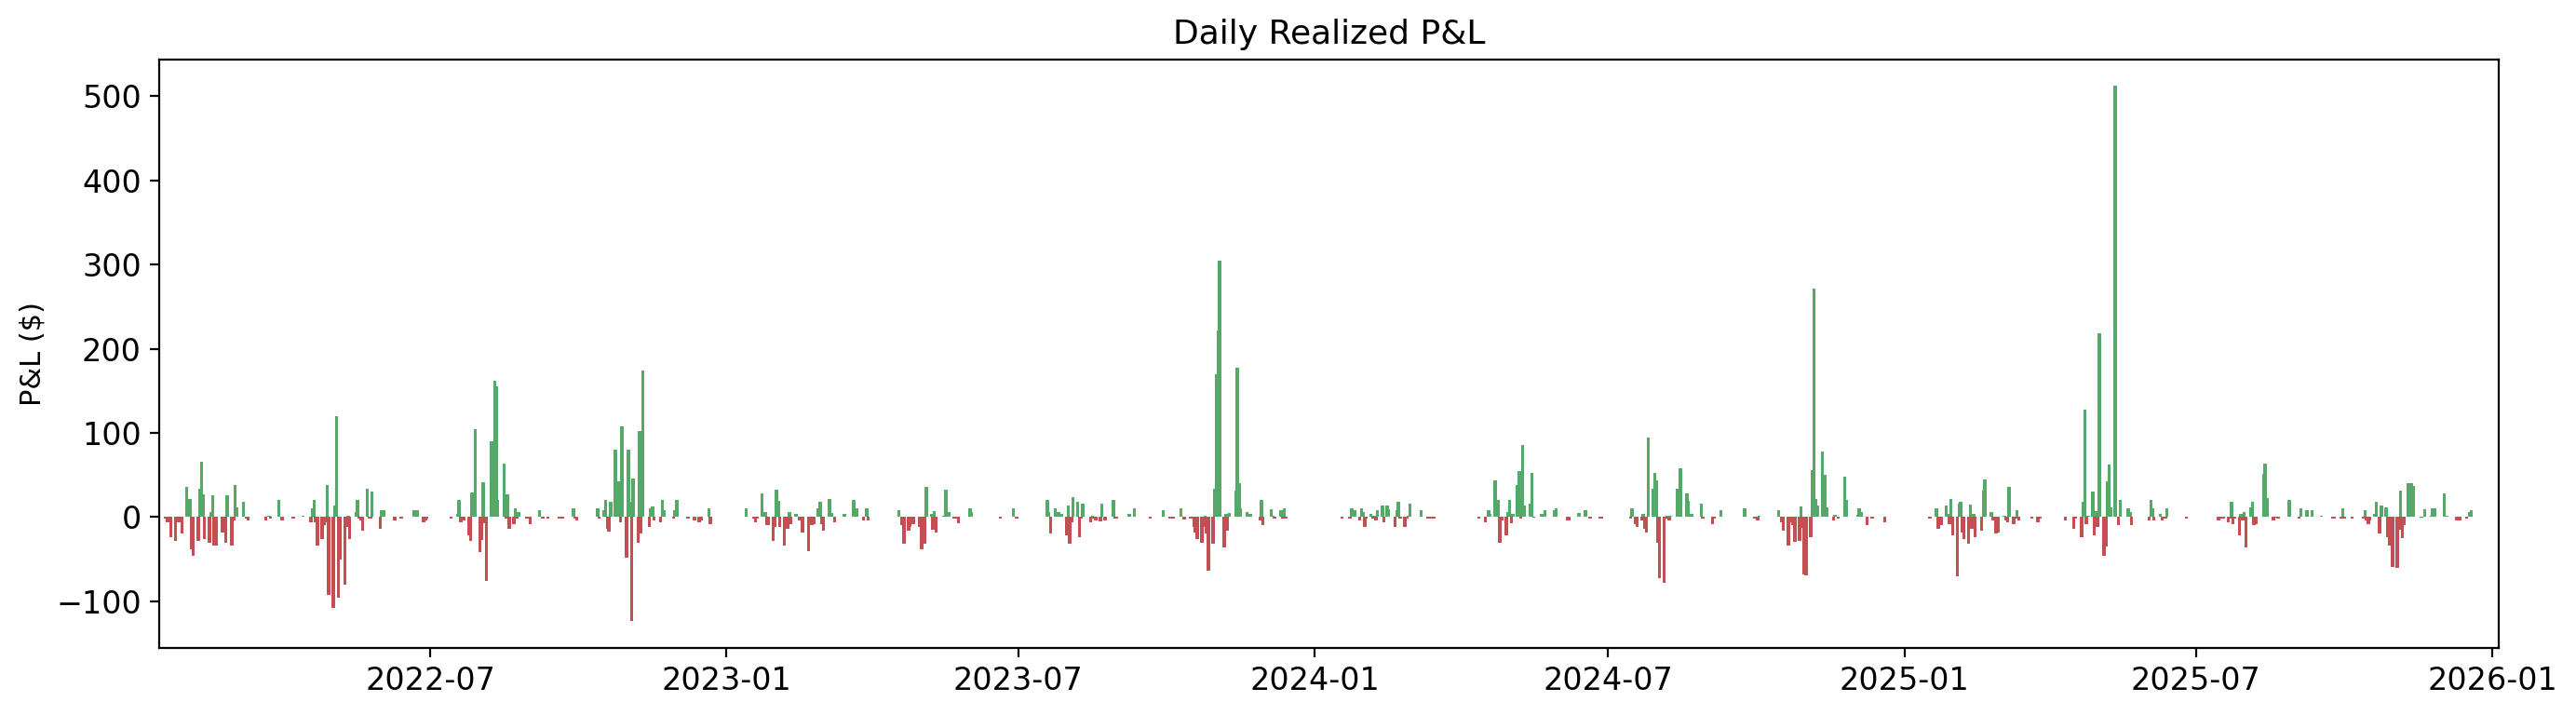

In [97]:
plt.figure(figsize=(14, 4)); colors = np.where(equity['pnl'].to_numpy() >= 0, '#55a868', '#c44e52'); plt.bar(equity['exit_date'], equity['pnl'], color=colors, width=2); plt.xlim(PLOT_START, PLOT_END); plt.title('Daily Realized P&L'); plt.ylabel('P&L ($)'); plt.tight_layout(); plt.show()


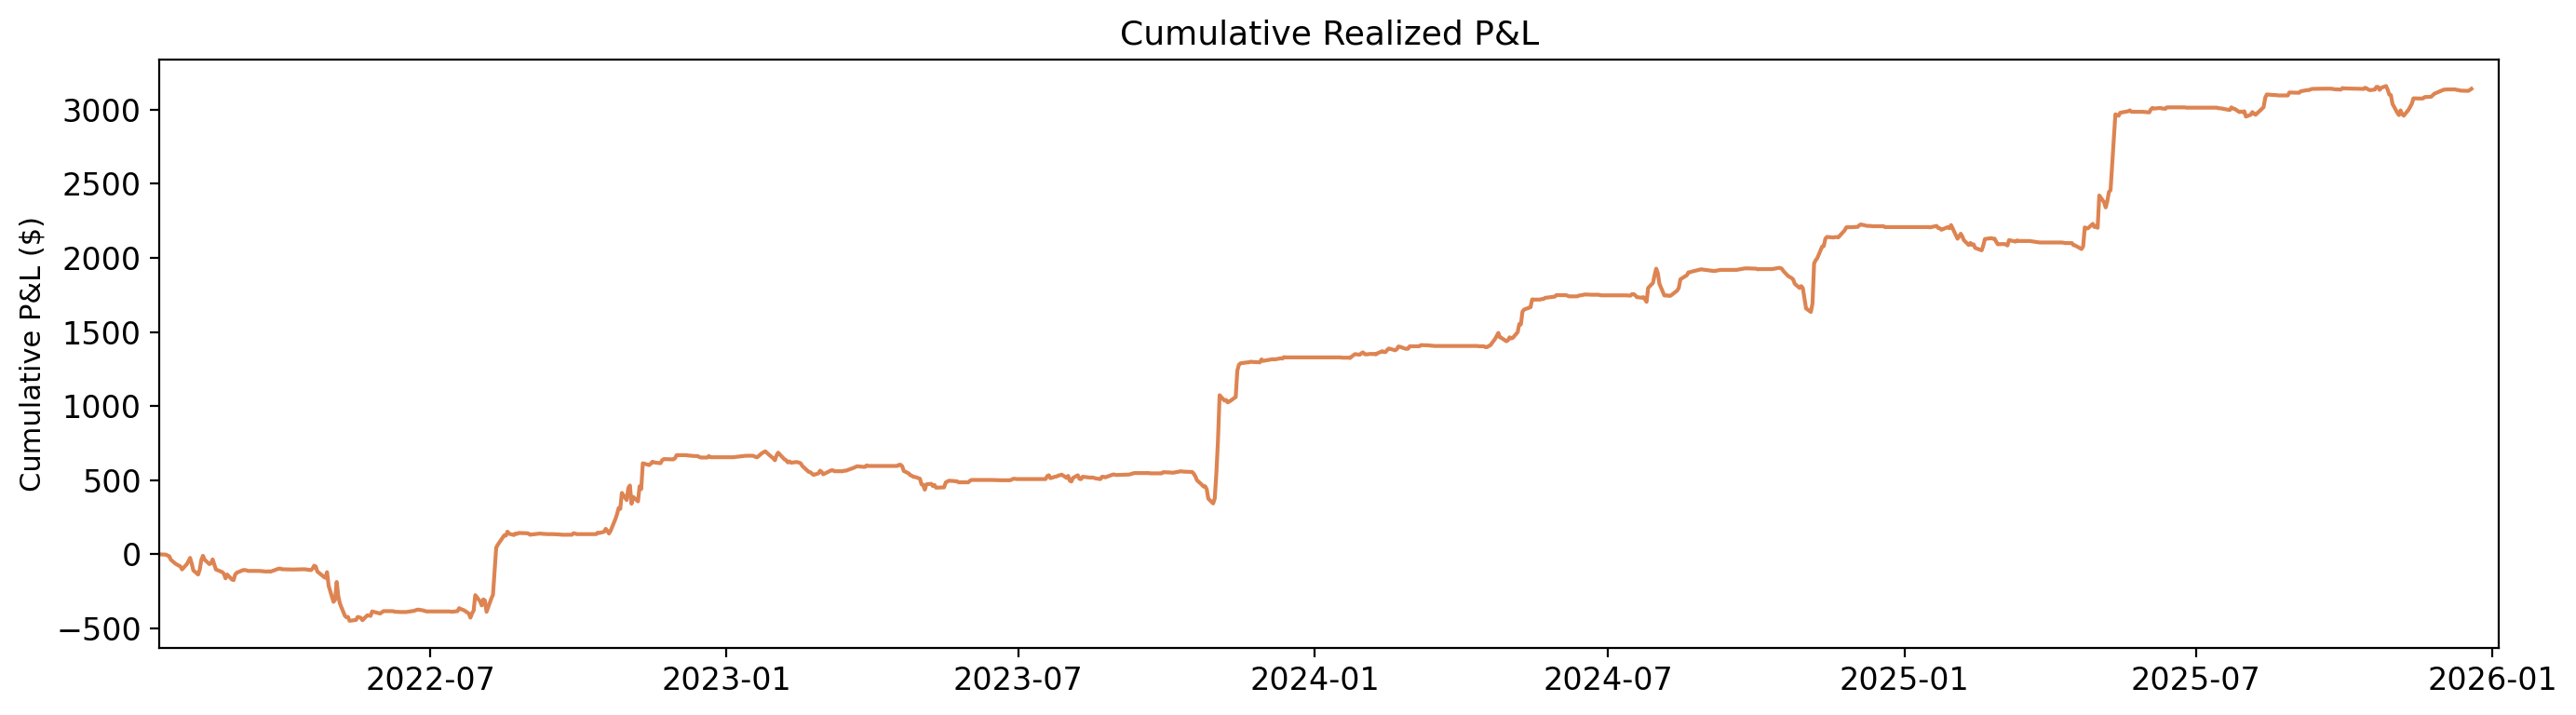

In [98]:
plt.figure(figsize=(14, 4)); plt.plot(equity['exit_date'], equity['pnl'].cum_sum(), color='#dd8452'); plt.xlim(PLOT_START, PLOT_END); plt.title('Cumulative Realized P&L'); plt.ylabel('Cumulative P&L ($)'); plt.tight_layout(); plt.show()


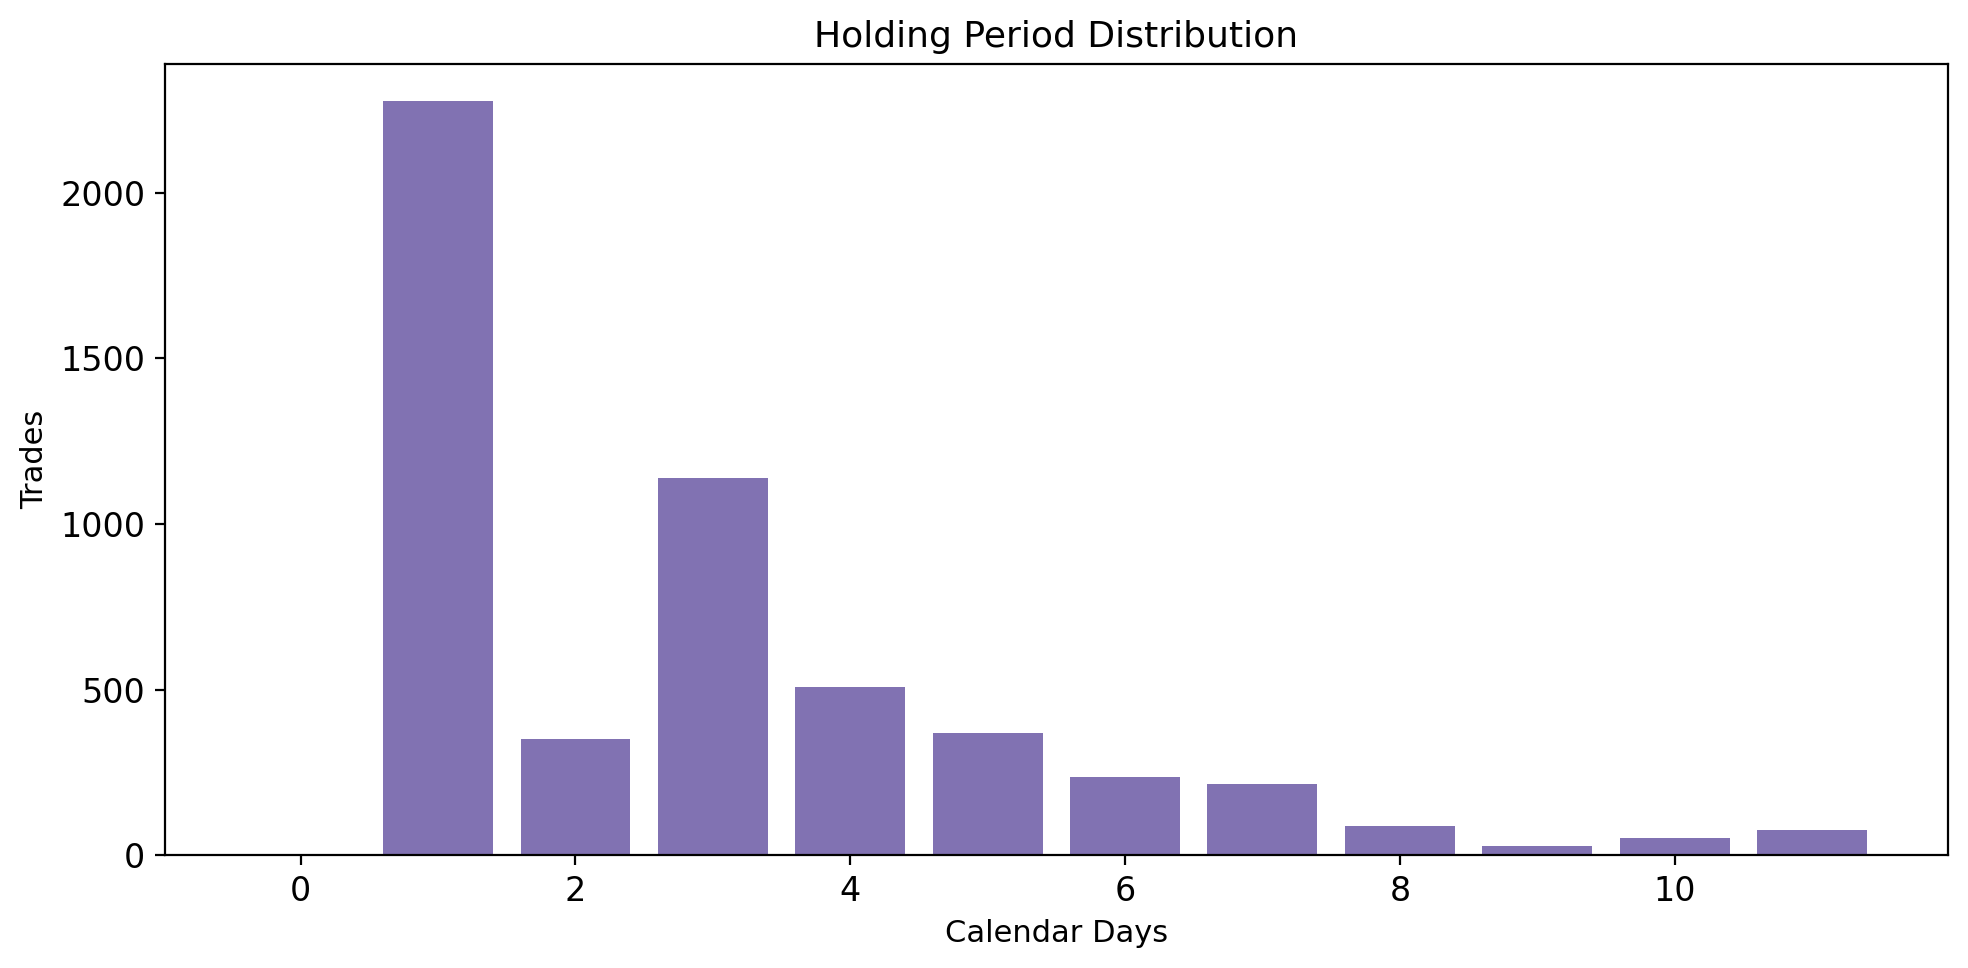

In [99]:
plt.figure(figsize=(10, 5)); plt.hist(trades['holding_days'].to_numpy(), bins=np.arange(0, 13) - .5, color='#8172b2', rwidth=.8); plt.title('Holding Period Distribution'); plt.xlabel('Calendar Days'); plt.ylabel('Trades'); plt.tight_layout(); plt.show()


In [100]:
exit_reason = trades.with_columns(
    pl.when(pl.col('net_pnl') >= POSITION_SIZE * TAKE_PROFIT - 1e-9)
      .then(pl.lit(f'{TAKE_PROFIT:.0%} take-profit'))
      .when(pl.col('net_pnl') <= POSITION_SIZE * STOP_LOSS + 1e-9)
      .then(pl.lit(f'{STOP_LOSS:.0%} stop-loss'))
      .otherwise(pl.lit('t+10 close'))
      .alias('reason')
)
exit_counts = exit_reason.group_by('reason').agg([
    pl.len().alias('count'),
    (pl.len() / exit_reason.height * 100).alias('pct'),
    pl.sum('net_pnl').alias('total_pnl'),
    pl.mean('net_pnl').alias('avg_pnl'),
])
print(exit_counts)


shape: (3, 5)
┌────────────────┬───────┬───────────┬────────────┬──────────┐
│ reason         ┆ count ┆ pct       ┆ total_pnl  ┆ avg_pnl  │
│ ---            ┆ ---   ┆ ---       ┆ ---        ┆ ---      │
│ str            ┆ u32   ┆ f64       ┆ f64        ┆ f64      │
╞════════════════╪═══════╪═══════════╪════════════╪══════════╡
│ 5% take-profit ┆ 1129  ┆ 19.989377 ┆ 11290.0    ┆ 10.0     │
│ -1% stop-loss  ┆ 4310  ┆ 76.310198 ┆ -8620.0    ┆ -2.0     │
│ t+10 close     ┆ 209   ┆ 3.700425  ┆ 882.904973 ┆ 4.224426 │
└────────────────┴───────┴───────────┴────────────┴──────────┘


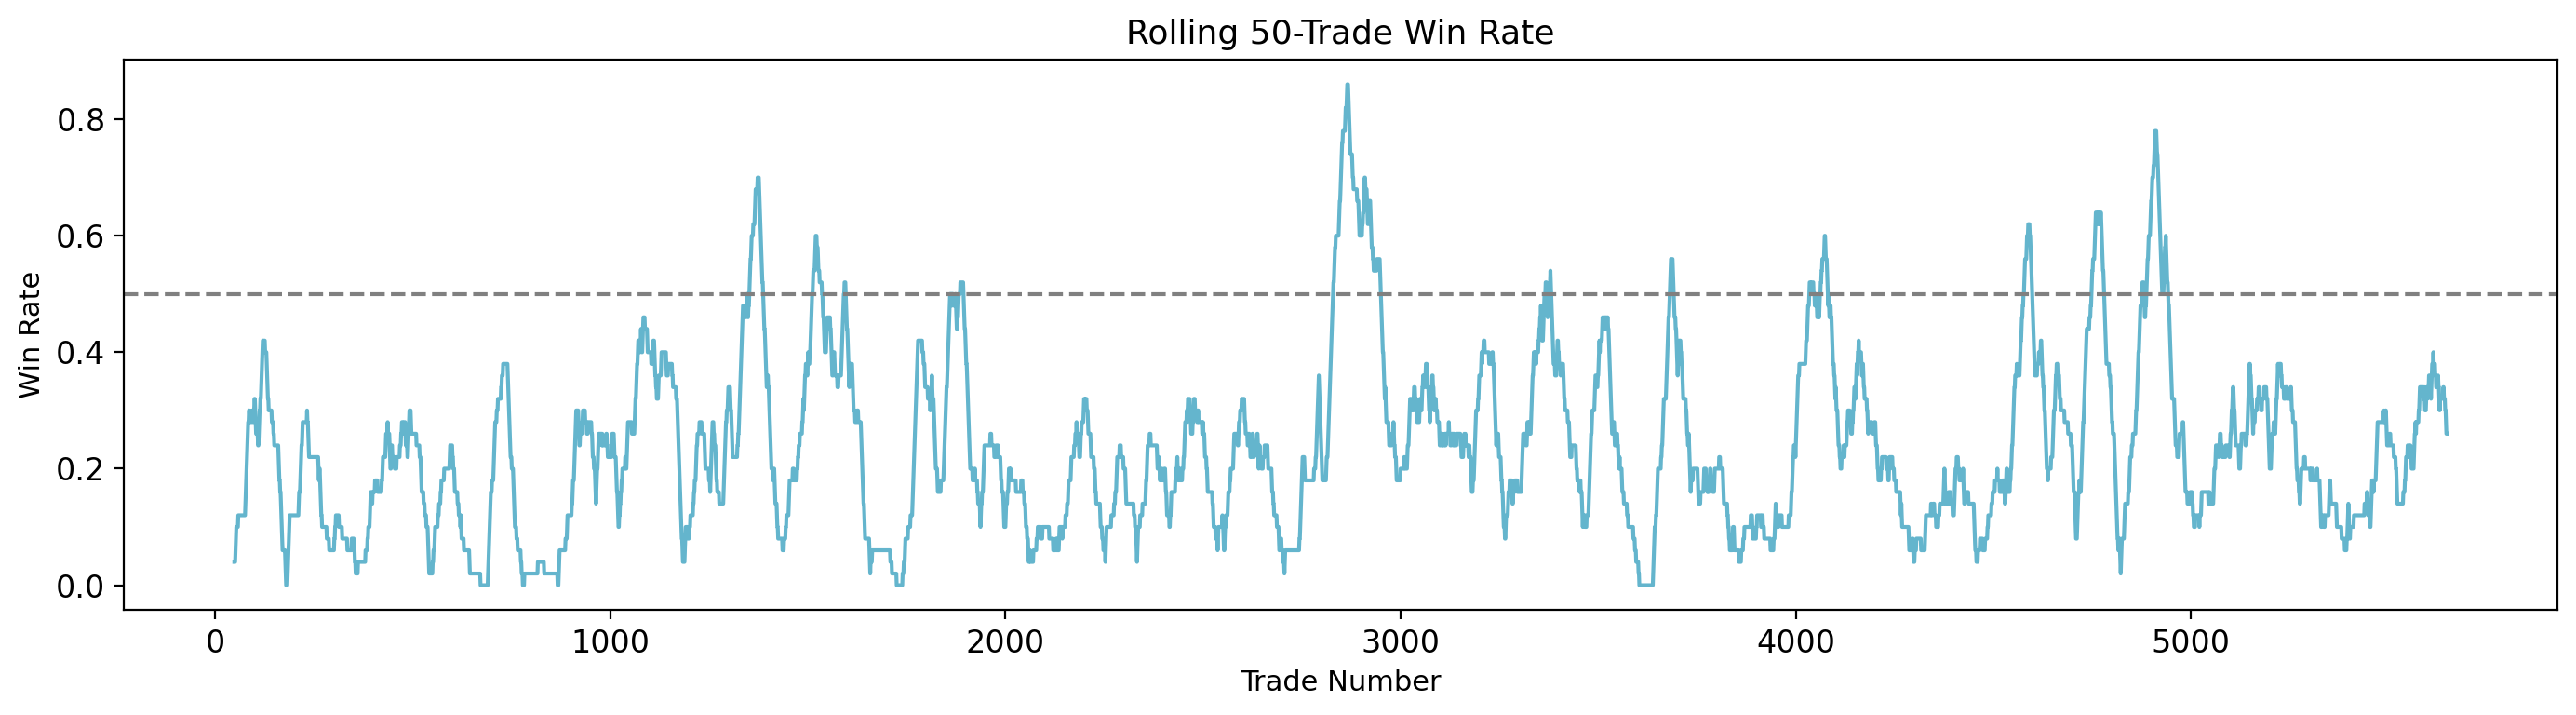

In [101]:
plt.figure(figsize=(14, 4)); plt.plot(np.arange(len(rolling_win)), rolling_win['win_rate'], color='#64b5cd'); plt.axhline(.5, color='gray', ls='--'); plt.title('Rolling 50-Trade Win Rate'); plt.xlabel('Trade Number'); plt.ylabel('Win Rate'); plt.tight_layout(); plt.show()


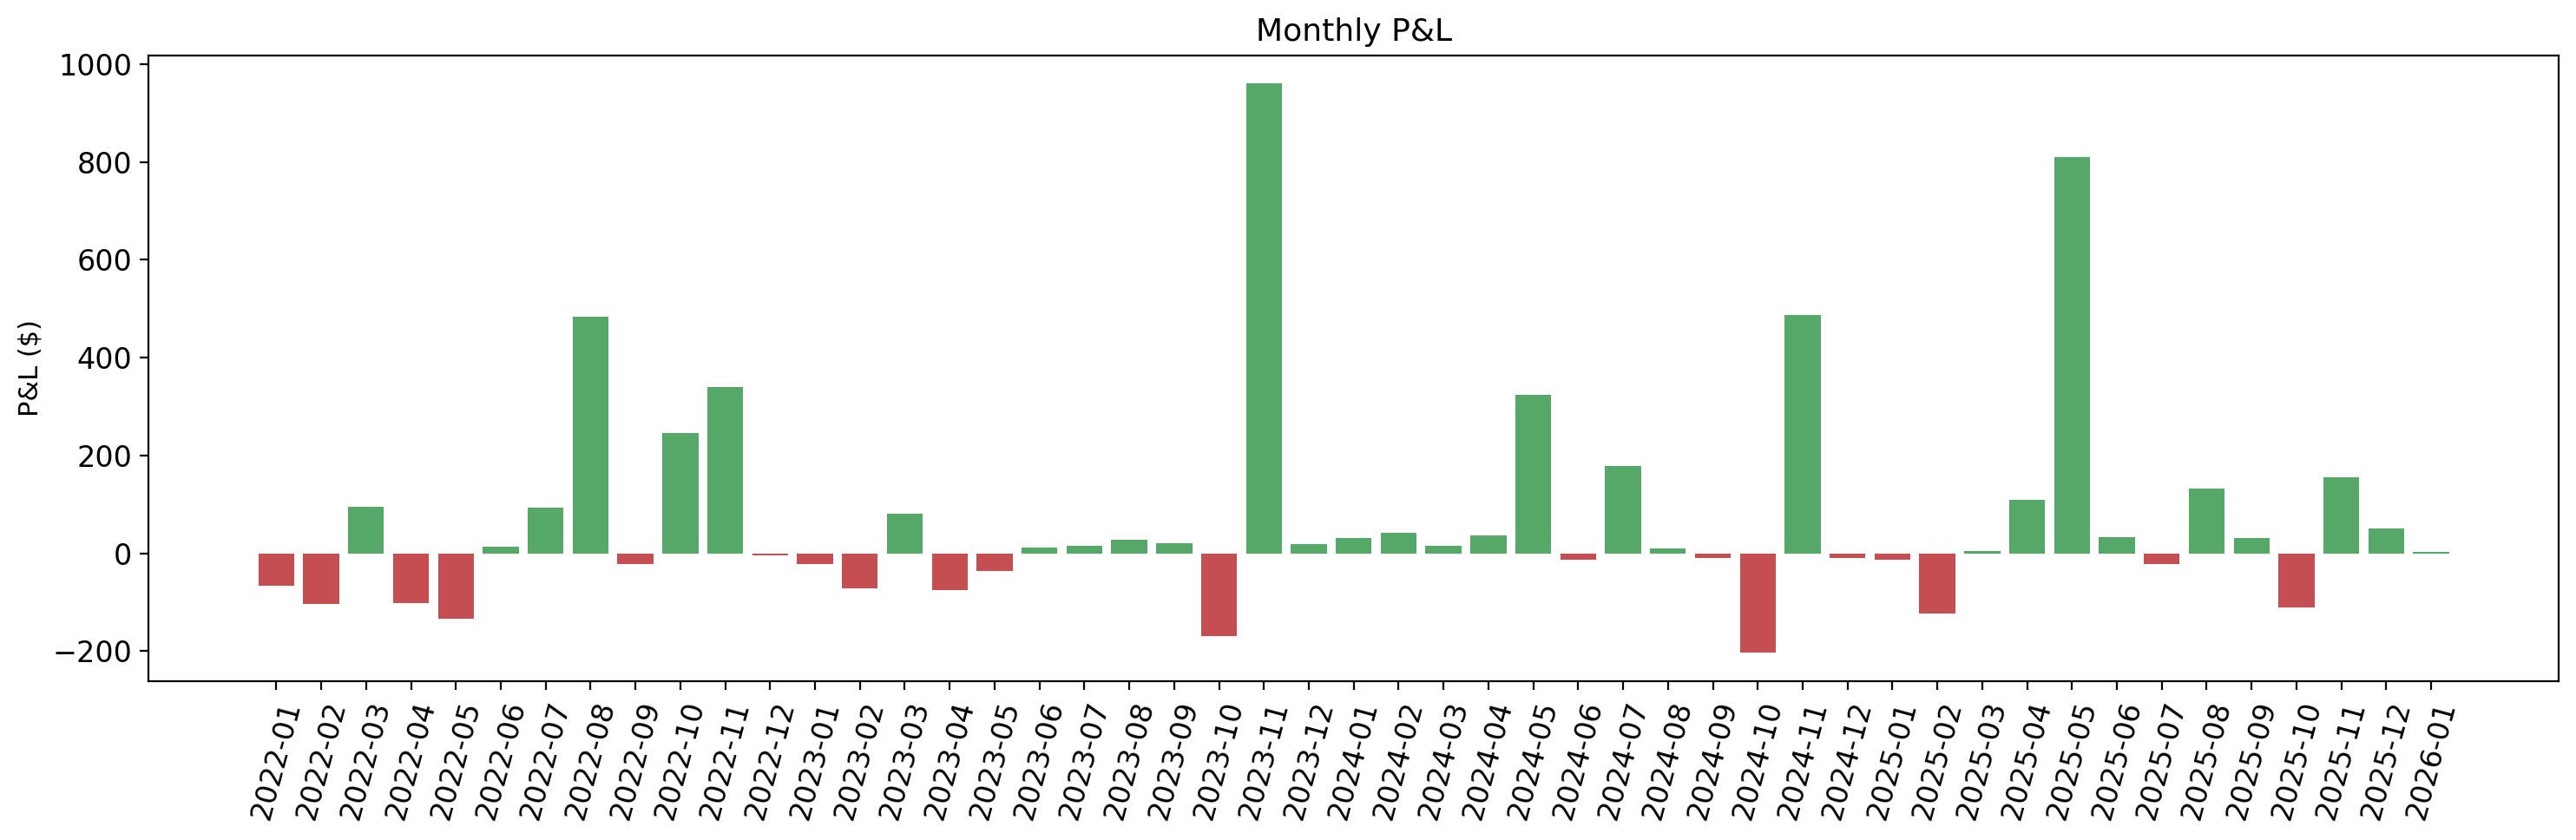

In [102]:
plt.figure(figsize=(15, 5)); plt.bar(monthly['month'].to_list(), monthly['pnl'], color=np.where(monthly['pnl'].to_numpy() >= 0, '#55a868', '#c44e52')); plt.title('Monthly P&L'); plt.xticks(rotation=75); plt.ylabel('P&L ($)'); plt.tight_layout(); plt.show()


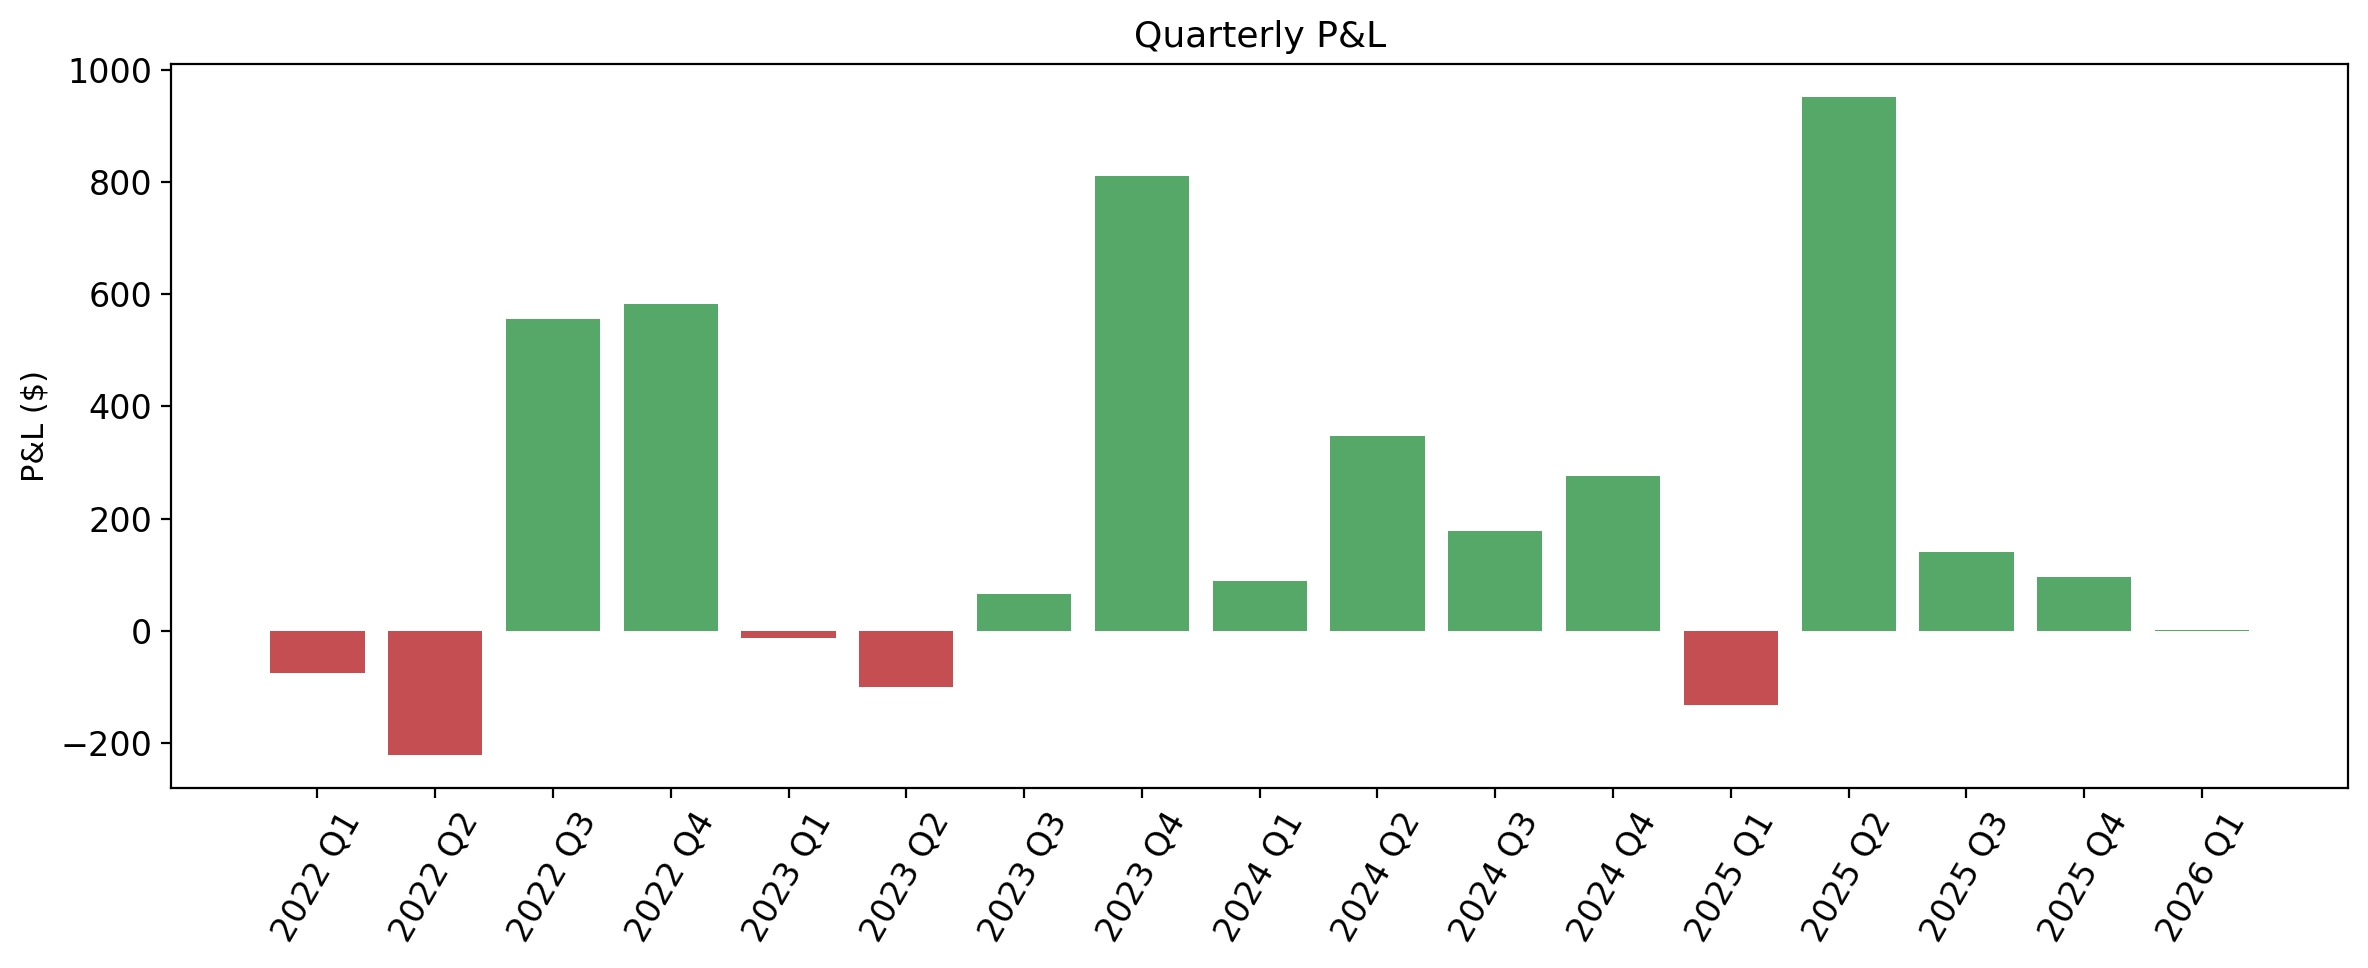

In [103]:
plt.figure(figsize=(12, 5)); plt.bar(quarterly['quarter'].to_list(), quarterly['pnl'], color=np.where(quarterly['pnl'].to_numpy() >= 0, '#55a868', '#c44e52')); plt.title('Quarterly P&L'); plt.xticks(rotation=60); plt.ylabel('P&L ($)'); plt.tight_layout(); plt.show()


In [108]:
activity 

date,entries,exits,open_positions,capital_exposure
date,u32,u32,u32,f64
2014-01-07,0,0,0,0.0
2014-01-08,0,0,0,0.0
2014-01-09,0,0,0,0.0
2014-01-14,0,0,0,0.0
2014-01-15,0,0,0,0.0
…,…,…,…,…
2025-12-12,3,2,183,36600.0
2025-12-16,0,1,182,36400.0
2025-12-17,1,0,183,36600.0


shape: (7, 6)
┌──────────────────┬──────────────┬───────────────────┬──────────────────┬──────────┬──────────┐
│ period           ┆ observations ┆ mean_daily_return ┆ daily_volatility ┆ sharpe   ┆ sortino  │
│ ---              ┆ ---          ┆ ---               ┆ ---              ┆ ---      ┆ ---      │
│ str              ┆ i64          ┆ f64               ┆ f64              ┆ f64      ┆ f64      │
╞══════════════════╪══════════════╪═══════════════════╪══════════════════╪══════════╪══════════╡
│ All trading days ┆ 2234         ┆ 0.000027          ┆ 0.000422         ┆ 1.030126 ┆ 1.194509 │
│ Exit days only   ┆ 568          ┆ 0.000108          ┆ 0.000832         ┆ 2.05434  ┆ 4.698123 │
│ (diagnostic)     ┆              ┆                   ┆                  ┆          ┆          │
│ 2021             ┆ 188          ┆ 0.0               ┆ 0.0              ┆ 0.0      ┆ 0.0      │
│ 2022             ┆ 183          ┆ 0.000071          ┆ 0.000763         ┆ 1.486741 ┆ 2.30253  │
│ 2023          

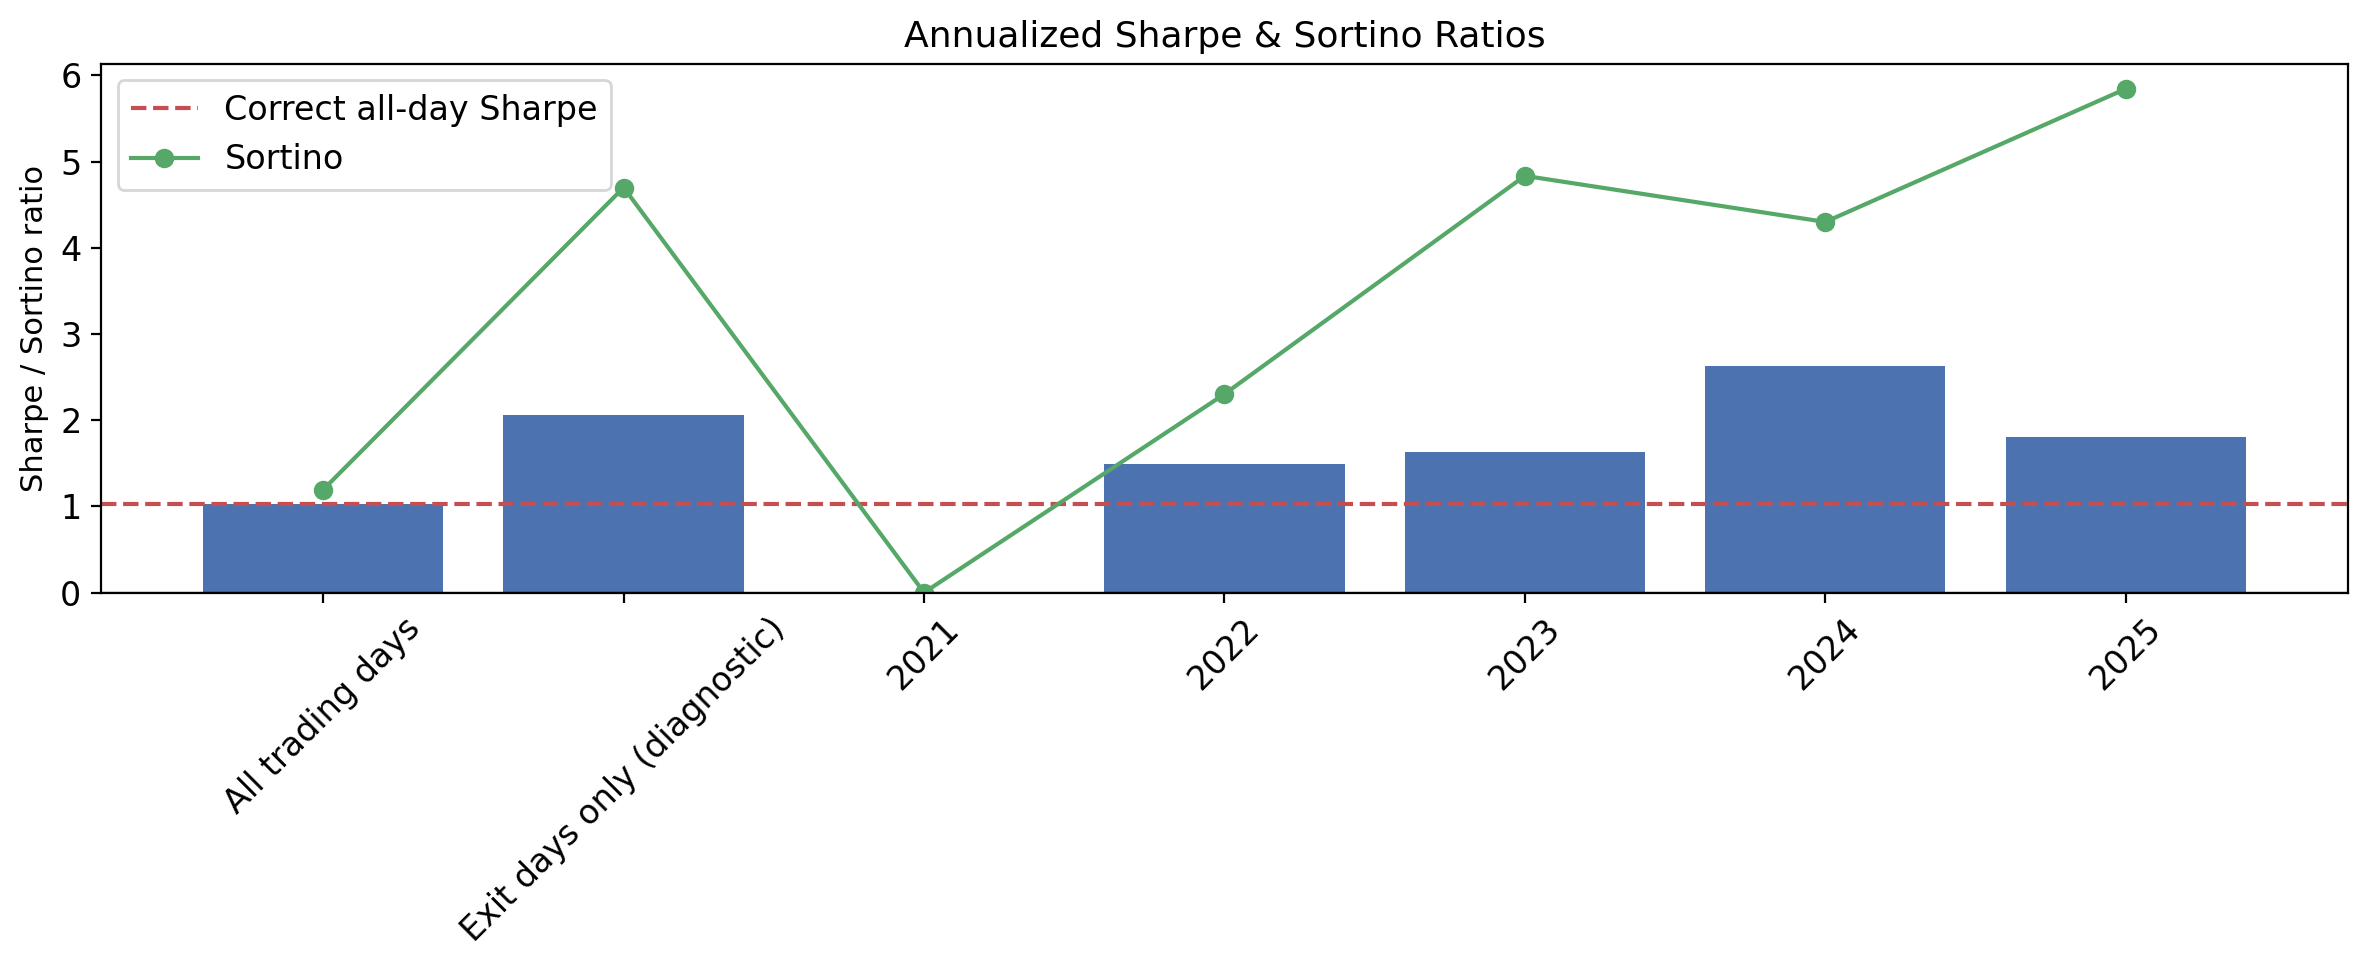

In [105]:
def annualized_sharpe(daily_returns):
    daily_returns = np.asarray(daily_returns, dtype=float)
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    if len(daily_returns) < 2 or daily_returns.std(ddof=1) == 0:
        return 0.0
    return float(daily_returns.mean() / daily_returns.std(ddof=1) * np.sqrt(252))

def annualized_sortino(daily_returns):
    daily_returns = np.asarray(daily_returns, dtype=float)
    daily_returns = daily_returns[np.isfinite(daily_returns)]
    downside = daily_returns[daily_returns < 0]
    if len(daily_returns) < 2 or len(downside) < 2 or downside.std(ddof=1) == 0:
        return 0.0
    return float(daily_returns.mean() / downside.std(ddof=1) * np.sqrt(252))

all_day_returns = equity['daily_return'].to_numpy()
exit_pnl = equity.filter(pl.col('pnl') != 0)['pnl'].to_numpy()
exit_equity = INITIAL_CAPITAL + np.cumsum(exit_pnl)
exit_previous = np.r_[INITIAL_CAPITAL, exit_equity[:-1]]
exit_day_returns = (exit_equity - exit_previous) / exit_previous

sharpe_rows = [{
    'period': 'All trading days',
    'observations': len(all_day_returns),
    'mean_daily_return': float(np.mean(all_day_returns)),
    'daily_volatility': float(np.std(all_day_returns, ddof=1)),
    'sharpe': annualized_sharpe(all_day_returns),
    'sortino': annualized_sortino(all_day_returns),
}, {
    'period': 'Exit days only (diagnostic)',
    'observations': len(exit_day_returns),
    'mean_daily_return': float(np.mean(exit_day_returns)),
    'daily_volatility': float(np.std(exit_day_returns, ddof=1)),
    'sharpe': annualized_sharpe(exit_day_returns),
    'sortino': annualized_sortino(exit_day_returns),
}]

for year in sorted(equity.select(pl.col('exit_date').dt.year().alias('year'))['year'].unique().to_list()):
    if year < 2021: continue
    year_returns = equity.filter(pl.col('exit_date').dt.year() == year)['daily_return'].to_numpy()
    if len(year_returns) > 1:
        sharpe_rows.append({'period': str(year), 'observations': len(year_returns), 'mean_daily_return': float(np.mean(year_returns)), 'daily_volatility': float(np.std(year_returns, ddof=1)), 'sharpe': annualized_sharpe(year_returns), 'sortino': annualized_sortino(year_returns)})

sharpe_table = pl.DataFrame(sharpe_rows)
print(sharpe_table)

plt.figure(figsize=(12, 5))
plt.bar(sharpe_table['period'], sharpe_table['sharpe'], color='#4c72b0')
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(sharpe_table[0, 'sharpe'], color='#c44e52', linestyle='--', label='Correct all-day Sharpe')
plt.plot(sharpe_table['period'], sharpe_table['sortino'], color='#55a868', marker='o', label='Sortino')
plt.title('Annualized Sharpe & Sortino Ratios')
plt.ylabel('Sharpe / Sortino ratio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
